# Event Study — Oil Shock, Green & Brown Assets

**Thesis:** Following the Iran-war oil shock (Feb 28, 2026), green firms earn significant
positive abnormal returns as investors reallocate capital toward clean-energy substitutes.

**Hypotheses**
- **H1:** Green firms (and ETFs) earn significantly positive CARs post-shock.
- **H2:** Oil-market volatility (Brent realized vol, WTI realized vol, OVX) partially explains those abnormal returns.



###  Imports & Configuration 

In [61]:
import warnings, json
warnings.filterwarnings("ignore")

from pathlib import Path
from numpy.linalg import lstsq

import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import acf, pacf, q_stat
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_arch
from scipy.stats import jarque_bera
from scipy.interpolate import make_interp_spline
# ── Plotting style ────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.grid": True,
    "grid.alpha": 0.20,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

GREEN   = "#155d66"
BROWN   = "#6b4247"
GREEN_L = "#03a598"
BROWN_L = "#b17261"
BLUE    = "#102e44"
ORANGE  = "#e68a00"
PURPLE  = "#634c62"
GREY    = "#636363"
GOLD    = "#d6b55c"

SECTOR_COLORS = {
    "Solar":             "#f4a700",
    "Wind":              "#1a9850",
    "EV & Battery":      "#4393c3",
    "Hydrogen/Fuel Cell":"#74add1",
    "Clean Utilities":   "#a6d96a",
    "Diversified Clean": "#66bd63",
    "Oil Majors":        "#d73027",
    "E&P / Services":    "#f46d43",
    "Refining":          "#fdae61",
    "Coal":              "#4d4d4d",
    "Gas & Midstream":   "#969696",
    "Diversified Fossil":"#bababa",
}

BASE_DIR  = Path.cwd()
CLEAN_DIR = BASE_DIR / "../data/clean"
FIG_DIR   = BASE_DIR / "../figures/event_study"
TAB_DIR   = BASE_DIR / "../tables/event_study"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

EVENT_ANNOUNCE = pd.Timestamp("2026-02-28")
EVENT_REACT    = pd.Timestamp("2026-03-02")

EST_START_OFFSET = -285
EST_END_OFFSET   = -35
MIN_OBS          = 80
BETA_SIG_LEVEL   = 0.10
HAC_LAGS         = 5
PCA_VAR_TARGET   = 0.80

EVENT_WINDOWS = [(-1,+1), (-3,+3), (-5,+5), (-7,+7),
                 (0,+7), (0,+10), (0,+15), (0,+20), (0,+25), (-25,+25), (-30,+30), (-10,+50), (-10,+60)]
WIN_LABELS    = [f"[{a:+d},{b:+d}]" for a, b in EVENT_WINDOWS]
PLOT_START, PLOT_END = -20, 60

def stars(p):
    if pd.isna(p): return ""
    if p < 0.01:   return "***"
    if p < 0.05:   return "**"
    if p < 0.10:   return "*"
    return ""

print(f"Event announced : {EVENT_ANNOUNCE.date()}")
print(f"t = 0           : {EVENT_REACT.date()}")
print(f"Estimation window offsets: [{EST_START_OFFSET}, {EST_END_OFFSET}]")
print(f"Event windows   : {WIN_LABELS}")

Event announced : 2026-02-28
t = 0           : 2026-03-02
Estimation window offsets: [-285, -35]
Event windows   : ['[-1,+1]', '[-3,+3]', '[-5,+5]', '[-7,+7]', '[+0,+7]', '[+0,+10]', '[+0,+15]', '[+0,+20]', '[+0,+25]', '[-25,+25]', '[-30,+30]', '[-10,+50]', '[-10,+60]']


### Data


Clean firm and ETF panels are loaded. A snapshot of the full universe is saved before
any event-study filtering is applied.

In [62]:
firm_panel = pd.read_csv(CLEAN_DIR / "firm_panel_clean.csv", parse_dates=["date"])
etf_panel  = pd.read_csv(CLEAN_DIR / "etf_panel_clean.csv",  parse_dates=["date"])

for df in [firm_panel, etf_panel]:
    df.sort_values(["ric", "date"], inplace=True)
    df.reset_index(drop=True, inplace=True)

firm_universe0 = firm_panel[["ric","company_name","energy_type"]].drop_duplicates("ric").copy()
etf_universe0  = etf_panel[["ric","asset_group"]].drop_duplicates("ric").copy()

for df, label, gc in [
    (firm_panel, "FIRM PANEL", "energy_type"),
    (etf_panel,  "ETF PANEL",  "asset_group"),
]:
    g = df[df[gc] == "green"]["ric"].nunique()
    b = df[df[gc] == "brown"]["ric"].nunique()
    print(f"\n{label}  |  shape {df.shape}  |  "
          f"{df['date'].min().date()} → {df['date'].max().date()}")
    print(f"  Green: {g}   Brown: {b}")


FIRM PANEL  |  shape (366751, 42)  |  2016-09-15 → 2026-08-28
  Green: 115   Brown: 153

ETF PANEL  |  shape (42000, 41)  |  2021-01-04 → 2026-08-28
  Green: 12   Brown: 18


### Event Calendar                                        

All dates are expressed as trading-day offsets relative to `t = 0`, defined as the first
U.S. market session after the Feb 28 announcement.

In [63]:
trading_days = pd.Series(firm_panel["date"].unique()).sort_values().reset_index(drop=True)
event_idx    = trading_days[trading_days >= EVENT_REACT].index[0]
event_dt     = trading_days.iloc[event_idx]
rel_day_map  = {dt: i - event_idx for i, dt in enumerate(trading_days)}

est_start_dt = trading_days.iloc[max(0, event_idx + EST_START_OFFSET)]
est_end_dt   = trading_days.iloc[max(0, event_idx + EST_END_OFFSET)]

MAX_WIN = max(max(abs(a), abs(b)) for a, b in EVENT_WINDOWS)

for df in [firm_panel, etf_panel]:
    df["t"]          = df["date"].map(rel_day_map)
    df["rf_daily"]   = df["RF"]
    df["excess_ret"] = df["log_return"] - df["rf_daily"]

print(f"t = 0             : {event_dt.date()}")
print(f"Estimation window : {est_start_dt.date()} → {est_end_dt.date()}")
print(f"t range           : {firm_panel['t'].min()} → {firm_panel['t'].max()}")
print("\nDays around event:")
print(firm_panel[["date","t"]].drop_duplicates()
      .set_index("t").sort_index().loc[-3:3])

t = 0             : 2026-03-02
Estimation window : 2025-01-06 → 2026-01-07
t range           : -1278 → 124

Days around event:
         date
t            
-3 2026-02-25
-2 2026-02-26
-1 2026-02-27
 0 2026-03-02
 1 2026-03-03
 2 2026-03-04
 3 2026-03-05


## Value-Weighted Realized Portfolio                 

Value-weighted realized returns are used for descriptive charts.

In [64]:
def vw_daily_return(panel, group_col, group,
                    ret_col="log_return", weight_col="market_cap"):
    sub = panel[
        (panel[group_col] == group) &
        panel[ret_col].notna() &
        panel[weight_col].notna() &
        (panel[weight_col] > 0)
    ].copy()
    out = (
        sub.groupby("date")
           .apply(lambda g: ((g[weight_col] / g[weight_col].sum()) * g[ret_col]).sum())
           .rename("vw_return")
           .reset_index()
    )
    out["group"] = group
    return out

firm_vw = pd.concat([
    vw_daily_return(firm_panel, "energy_type", "green"),
    vw_daily_return(firm_panel, "energy_type", "brown"),
], ignore_index=True)

etf_vw = pd.concat([
    vw_daily_return(etf_panel, "asset_group", "green"),
    vw_daily_return(etf_panel, "asset_group", "brown"),
], ignore_index=True)

print("Firm VW realized return summary:")
print(firm_vw.groupby("group")["vw_return"].describe().round(5))

Firm VW realized return summary:
        count     mean      std      min      25%      50%      75%      max
group                                                                       
brown  1399.0  0.00100  0.01595 -0.09383 -0.00795  0.00171  0.01024  0.07269
green  1399.0  0.00041  0.01932 -0.08061 -0.01096  0.00090  0.01184  0.11590


### Oil-Volatility Variables                         

Three oil-volatility proxies are checked: Brent Parkinson realized volatility,
WTI Parkinson realized volatility, and OVX (CBOE implied oil volatility).

In [65]:
oil_candidates = ["brent_parkinson_vol", "wti_parkinson_vol", "ovx_close"]

for col in oil_candidates:
    if col in firm_panel.columns:
        x = firm_panel[["date", col]].drop_duplicates("date")[col]
        print(f"{col:<25}  mean={x.mean():.4f}  std={x.std():.4f}  NaN={x.isna().sum()}")
    else:
        print(f"{col:<25}  NOT AVAILABLE")

brent_parkinson_vol        mean=0.0006  std=0.0015  NaN=2
wti_parkinson_vol          mean=0.0007  std=0.0018  NaN=3
ovx_close                  mean=41.6487  std=13.0317  NaN=3


Estimation window correlations:
           Mkt-RF    SMB    HML  Brent Vol  WTI Vol    OVX
Mkt-RF      1.000  0.176 -0.374      0.103    0.088 -0.001
SMB         0.176  1.000  0.214     -0.016   -0.029 -0.032
HML        -0.374  0.214  1.000     -0.151   -0.156 -0.092
Brent Vol   0.103 -0.016 -0.151      1.000    0.992  0.470
WTI Vol     0.088 -0.029 -0.156      0.992    1.000  0.484
OVX        -0.001 -0.032 -0.092      0.470    0.484  1.000

Event window correlations:
           Mkt-RF    SMB    HML  Brent Vol  WTI Vol    OVX
Mkt-RF      1.000  0.378 -0.451      0.104    0.150 -0.093
SMB         0.378  1.000  0.039      0.070    0.032 -0.056
HML        -0.451  0.039  1.000     -0.162   -0.169  0.010
Brent Vol   0.104  0.070 -0.162      1.000    0.971  0.306
WTI Vol     0.150  0.032 -0.169      0.971    1.000  0.320
OVX        -0.093 -0.056  0.010      0.306    0.320  1.000


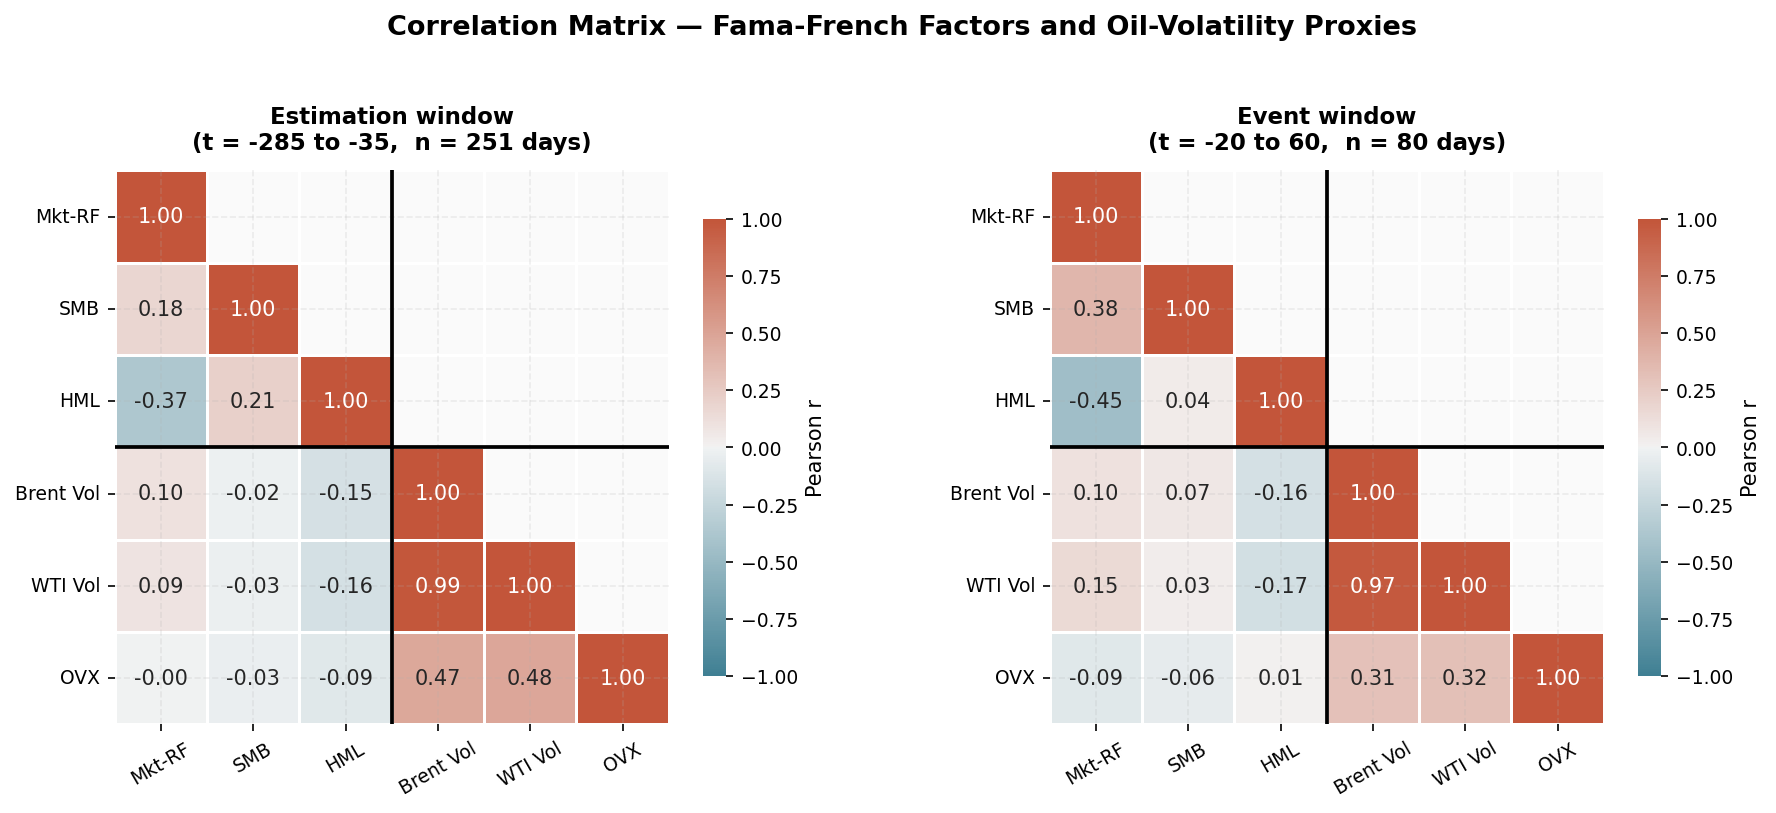

Saved → factor_oilvol_correlation_heatmap.png


In [66]:
# ═══════════════════════════════════════════════════════════════════════════════
# CORRELATION HEATMAP — Fama-French factors vs. oil-volatility proxies
# Two panels: estimation window  |  event window
# ═══════════════════════════════════════════════════════════════════════════════

import seaborn as sns

factor_cols = ["Mkt_RF", "SMB", "HML"]
oil_cols    = [c for c in ["brent_parkinson_vol", "wti_parkinson_vol", "ovx_close"]
               if c in firm_panel.columns]
all_cols    = factor_cols + oil_cols

rename_map = {
    "Mkt_RF":              "Mkt-RF",
    "SMB":                 "SMB",
    "HML":                 "HML",
    "brent_parkinson_vol": "Brent Vol",
    "wti_parkinson_vol":   "WTI Vol",
    "ovx_close":           "OVX",
}

def corr_for_window(panel, t_lo, t_hi):
    """One observation per date, filtered to t in [t_lo, t_hi]."""
    sub = (panel[panel["t"].between(t_lo, t_hi)]
           [["date"] + all_cols]
           .drop_duplicates("date")
           .dropna(subset=all_cols)
           .set_index("date")[all_cols])
    cm = sub.corr().rename(index=rename_map, columns=rename_map)
    n  = len(sub)
    return cm, n

cm_est,  n_est  = corr_for_window(firm_panel, EST_START_OFFSET, EST_END_OFFSET)
cm_event, n_ev  = corr_for_window(firm_panel, PLOT_START, PLOT_END)

print("Estimation window correlations:")
print(cm_est.round(3).to_string())
print(f"\nEvent window correlations:")
print(cm_event.round(3).to_string())

# ── Plot ──────────────────────────────────────────────────────────────────────
n_ff   = len(factor_cols)          # index of block separator
cmap   = sns.diverging_palette(220, 20, as_cmap=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5),
                         gridspec_kw={"wspace": 0.35})

for ax, cm, n_obs, window_label in [
    (axes[0], cm_est,   n_est, f"Estimation window\n(t = {EST_START_OFFSET} to {EST_END_OFFSET},  n = {n_est} days)"),
    (axes[1], cm_event, n_ev,  f"Event window\n(t = {PLOT_START} to {PLOT_END},  n = {n_ev} days)"),
]:
    mask = np.zeros_like(cm.values, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True   # keep lower triangle + diagonal

    sns.heatmap(
        cm,
        mask      = mask,
        cmap      = cmap,
        vmin=-1, vmax=1, center=0,
        annot     = True,
        fmt       = ".2f",
        annot_kws = {"size": 10},
        square    = True,
        linewidths= 0.5,
        cbar_kws  = {"shrink": 0.72, "label": "Pearson r"},
        ax        = ax,
    )

    # Block separator between FF factors and oil-vol proxies
    ax.axhline(n_ff, color="black", lw=1.8)
    ax.axvline(n_ff, color="black", lw=1.8)

    ax.set_title(window_label, fontsize=11, fontweight="bold", pad=10)
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Correlation Matrix — Fama-French Factors and Oil-Volatility Proxies",
    fontsize=13, fontweight="bold", y=1.02,
)

plt.savefig(FIG_DIR / "factor_oilvol_correlation_heatmap.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Saved → factor_oilvol_correlation_heatmap.png")

### Expected-Return Models

#### OLS with HAC (Newey–West) Inference

Coefficients are estimated by OLS over the estimation window
$t \in [T_1, T_2] = [-285, -35]$. Standard errors use the Newey–West HAC correction:

$$
\hat{V}_{\text{HAC}} = (X^\top X)^{-1}\, \hat{S} \,(X^\top X)^{-1}
$$

where the long-run covariance matrix $\hat{S}$ is

$$
\hat{S} = \sum_{t} x_t x_t^\top \hat{\varepsilon}_t^2
+ \sum_{\ell=1}^{L} w_\ell \sum_{t > \ell}
\bigl(x_t \hat{\varepsilon}_t x_{t-\ell}^\top \hat{\varepsilon}_{t-\ell}
     + x_{t-\ell} \hat{\varepsilon}_{t-\ell} x_t^\top \hat{\varepsilon}_t\bigr),
\quad w_\ell = 1 - \frac{\ell}{L+1}
$$

with $L = 5$ Bartlett lags.

#### Model Specifications

| Model | Regression equation |
|---|---|
| **CAPM** | $r_{i,t} - r_{f,t} = \alpha_i + \beta_i (r_{m,t} - r_{f,t}) + \varepsilon_{i,t}$ |
| **FF3** | $r_{i,t} - r_{f,t} = \alpha_i + \beta_i \text{MktRF}_t + s_i \text{SMB}_t + h_i \text{HML}_t + \varepsilon_{i,t}$ |
| **CAPM + BrentVol** | CAPM augmented with Brent realized volatility |
| **FF3 + BrentVol** | FF3 augmented with Brent realized volatility |
| **CAPM + OVX** | CAPM augmented with OVX |
| **FF3 + OVX** | FF3 augmented with OVX |

In [67]:
def ols_hac_inference(X, y, param_names, n_lags=HAC_LAGS):
    n, k  = X.shape
    b, _, _, _ = lstsq(X, y, rcond=None)
    resid = y - X @ b
    df_e  = n - k
    XtXi  = np.linalg.inv(X.T @ X)

    Xe = X * resid[:, None]
    S  = Xe.T @ Xe
    for lag in range(1, min(n_lags, n - 1) + 1):
        w     = 1 - lag / (n_lags + 1)
        gamma = Xe[lag:].T @ Xe[:-lag]
        S    += w * (gamma + gamma.T)

    V   = XtXi @ S @ XtXi
    se  = np.sqrt(np.maximum(np.diag(V), 0))
    tst = b / (se + 1e-30)
    pv  = 2 * stats.t.sf(np.abs(tst), df=max(df_e, 1))

    ss_res = resid @ resid
    ss_tot = ((y - y.mean()) @ (y - y.mean()))
    r2     = 1 - ss_res / (ss_tot + 1e-30)
    adj_r2 = 1 - (1 - r2) * (n - 1) / max(df_e, 1)

    return {
        "b": dict(zip(param_names, b)),
        "se": dict(zip(param_names, se)),
        "t": dict(zip(param_names, tst)),
        "p": dict(zip(param_names, pv)),
        "resid": resid,
        "r2": r2, "adj_r2": adj_r2, "n": n,
    }

model_specs = {
    "CAPM":          (["Mkt_RF"],                          ["alpha","Mkt"]),
    "FF3":           (["Mkt_RF","SMB","HML"],              ["alpha","Mkt","SMB","HML"]),
    "CAPM+BrentVol": (["Mkt_RF","brent_parkinson_vol"],    ["alpha","Mkt","BrentVol"]),
    "FF3+BrentVol":  (["Mkt_RF","SMB","HML","brent_parkinson_vol"],
                                                           ["alpha","Mkt","SMB","HML","BrentVol"]),
    "CAPM+OVX":      (["Mkt_RF","ovx_close"],              ["alpha","Mkt","OVX"]),
    "FF3+OVX":       (["Mkt_RF","SMB","HML","ovx_close"],  ["alpha","Mkt","SMB","HML","OVX"]),
}
if "wti_parkinson_vol" in firm_panel.columns:
    model_specs["CAPM+WTIVol"] = (["Mkt_RF","wti_parkinson_vol"],
                                   ["alpha","Mkt","WTIVol"])
    model_specs["FF3+WTIVol"]  = (["Mkt_RF","SMB","HML","wti_parkinson_vol"],
                                   ["alpha","Mkt","SMB","HML","WTIVol"])

print("Model specifications:")
for m, (cols, _) in model_specs.items():
    print(f"  {m:<18}: {cols}")

Model specifications:
  CAPM              : ['Mkt_RF']
  FF3               : ['Mkt_RF', 'SMB', 'HML']
  CAPM+BrentVol     : ['Mkt_RF', 'brent_parkinson_vol']
  FF3+BrentVol      : ['Mkt_RF', 'SMB', 'HML', 'brent_parkinson_vol']
  CAPM+OVX          : ['Mkt_RF', 'ovx_close']
  FF3+OVX           : ['Mkt_RF', 'SMB', 'HML', 'ovx_close']
  CAPM+WTIVol       : ['Mkt_RF', 'wti_parkinson_vol']
  FF3+WTIVol        : ['Mkt_RF', 'SMB', 'HML', 'wti_parkinson_vol']


In [68]:
def estimate_models(panel, group_col, label):
    params  = {m: {} for m in model_specs}
    est_base = panel[panel["t"].between(EST_START_OFFSET, EST_END_OFFSET)].copy()

    for ric, grp0 in est_base.groupby("ric"):
        name  = grp0["company_name"].iloc[0] if "company_name" in grp0.columns else ric
        group = grp0[group_col].iloc[0]

        for model, (cols, pnames) in model_specs.items():
            grp = grp0.dropna(subset=["excess_ret"] + cols).copy()
            if len(grp) < MIN_OBS:
                continue
            y = grp["excess_ret"].values
            X = np.c_[np.ones(len(grp)), grp[cols].values]
            try:
                res = ols_hac_inference(X, y, pnames)
            except Exception:
                continue
            res.update({"ric": ric, "name": str(name)[:45],
                        "group": group, "model": model})
            params[model][ric] = res

    print(f"\n{label}")
    for model in params:
        print(f"  {model:<18}: {len(params[model])} assets")
    return params

firm_params = estimate_models(firm_panel, "energy_type", "FIRMS")
etf_params  = estimate_models(etf_panel,  "asset_group",  "ETFs")


FIRMS
  CAPM              : 268 assets
  FF3               : 268 assets
  CAPM+BrentVol     : 268 assets
  FF3+BrentVol      : 268 assets
  CAPM+OVX          : 268 assets
  FF3+OVX           : 268 assets
  CAPM+WTIVol       : 268 assets
  FF3+WTIVol        : 268 assets

ETFs
  CAPM              : 30 assets
  FF3               : 30 assets
  CAPM+BrentVol     : 30 assets
  FF3+BrentVol      : 30 assets
  CAPM+OVX          : 30 assets
  FF3+OVX           : 30 assets
  CAPM+WTIVol       : 30 assets
  FF3+WTIVol        : 30 assets


#### Beta Report, Eligibility, and Filtered Panels

Assets are retained only if: (i) the CAPM market beta is statistically significant at
the 10% level, and (ii) at least one FF3 factor loading is significant at the 10% level.

In [69]:
def make_beta_report(params, label):
    rows = []
    for model, mp in params.items():
        for ric, p in mp.items():
            row = {"universe": label, "ric": ric, "name": p["name"],
                   "group": p["group"], "model": model,
                   "n_obs": p["n"], "r2": p["r2"]}
            for factor in p["b"]:
                row[f"beta_{factor}"] = p["b"][factor]
                row[f"t_{factor}"]    = p["t"][factor]
                row[f"p_{factor}"]    = p["p"][factor]
                row[f"sig_{factor}"]  = p["p"][factor] < BETA_SIG_LEVEL
            rows.append(row)
    return pd.DataFrame(rows)

def eligible_ids(beta_report):
    capm = beta_report[beta_report["model"] == "CAPM"]
    ff3  = beta_report[beta_report["model"] == "FF3"]
    capm_keep = set(capm.loc[capm["p_Mkt"] < BETA_SIG_LEVEL, "ric"])
    ff3_pcols = [c for c in ["p_Mkt","p_SMB","p_HML"] if c in ff3.columns]
    ff3_keep  = set(ff3[ff3[ff3_pcols].lt(BETA_SIG_LEVEL).any(axis=1)]["ric"])
    return capm_keep & ff3_keep

def dropped_report(universe0, keep_ids, beta_report, group_col, label):
    base = universe0.rename(columns={group_col: "group"}).copy()
    base["kept"] = base["ric"].isin(keep_ids)

    capm = (beta_report[beta_report["model"] == "CAPM"]
            [["ric","p_Mkt","beta_Mkt","r2","n_obs"]]
            .rename(columns={"p_Mkt":"capm_p_mkt","beta_Mkt":"capm_beta_mkt",
                              "r2":"capm_r2","n_obs":"capm_n"}))
    ff3_keep_cols = [c for c in ["ric","p_Mkt","p_SMB","p_HML","r2","n_obs"]
                     if c in beta_report.columns]
    ff3 = (beta_report[beta_report["model"] == "FF3"][ff3_keep_cols]
           .rename(columns={"p_Mkt":"ff3_p_mkt","p_SMB":"ff3_p_smb",
                             "p_HML":"ff3_p_hml","r2":"ff3_r2","n_obs":"ff3_n"}))

    out = base.merge(capm, on="ric", how="left").merge(ff3, on="ric", how="left")

    def reason(row):
        if row["kept"]:                                        return "kept"
        if pd.isna(row.get("capm_p_mkt")):                    return "dropped: CAPM not estimated"
        if row.get("capm_p_mkt", 1) >= BETA_SIG_LEVEL:        return "dropped: CAPM β(Mkt) not sig"
        if pd.isna(row.get("ff3_p_mkt")):                     return "dropped: FF3 not estimated"
        pv = [row.get("ff3_p_mkt"), row.get("ff3_p_smb"), row.get("ff3_p_hml")]
        if not any(pd.notna(p) and p < BETA_SIG_LEVEL for p in pv):
            return "dropped: no sig FF3 factor"
        return "dropped: other"

    out["status"] = out.apply(reason, axis=1)
    print(f"\n{label} — dropped/kept breakdown")
    print(out.groupby(["group","status"])["ric"].nunique().to_string())
    return out

# ── Run ───────────────────────────────────────────────────────────────
firm_beta_report = make_beta_report(firm_params, "Firms")
etf_beta_report  = make_beta_report(etf_params,  "ETFs")

firm_keep_ids = eligible_ids(firm_beta_report)
etf_keep_ids  = eligible_ids(etf_beta_report)

firm_panel_sig = firm_panel[firm_panel["ric"].isin(firm_keep_ids)].copy()
etf_panel_sig  = etf_panel[etf_panel["ric"].isin(etf_keep_ids)].copy()

print(f"\nEligible firms : {len(firm_keep_ids)}")
print(firm_panel_sig.groupby("energy_type")["ric"].nunique().rename("n_firms"))
print(f"\nEligible ETFs  : {len(etf_keep_ids)}")
print(etf_panel_sig.groupby("asset_group")["ric"].nunique().rename("n_etfs"))

firm_drop_report = dropped_report(firm_universe0, firm_keep_ids,
                                  firm_beta_report, "energy_type", "FIRMS")
etf_drop_report  = dropped_report(etf_universe0,  etf_keep_ids,
                                  etf_beta_report,  "asset_group",  "ETFs")


Eligible firms : 252
energy_type
brown    148
green    104
Name: n_firms, dtype: int64

Eligible ETFs  : 29
asset_group
brown    17
green    12
Name: n_etfs, dtype: int64

FIRMS — dropped/kept breakdown
group  status                      
brown  dropped: CAPM β(Mkt) not sig      4
       dropped: no sig FF3 factor        1
       kept                            148
green  dropped: CAPM β(Mkt) not sig     10
       dropped: no sig FF3 factor        1
       kept                            104

ETFs — dropped/kept breakdown
group  status                      
brown  dropped: CAPM β(Mkt) not sig     1
       kept                            17
green  kept                            12


### Descriptive Statistics

In [70]:
def filtered_sample_desc(panel, group_col, label):
    """
    Descriptive statistics for the beta-filtered sample.
    Reports: N assets, N obs, mean/SD of log return and excess return,
    market cap statistics, and estimation-window R² from the CAPM regression.
    """
    rows = []
    params_ref = firm_params if label == "Firms" else etf_params

    for group, g in panel.groupby(group_col):
        rics  = g["ric"].unique()
        ret   = g["log_return"].dropna()
        xret  = g["excess_ret"].dropna()
        mcap  = g["market_cap"].dropna() if "market_cap" in g.columns else pd.Series(dtype=float)

        # CAPM R² for assets in this group
        r2_vals = [params_ref["CAPM"][r]["r2"]
                   for r in rics if r in params_ref.get("CAPM", {})]

        rows.append({
            "Universe":         label,
            "Group":            group,
            "N assets":         g["ric"].nunique(),
            "N obs":            len(ret),
            "Mean log-ret (%)": round(ret.mean()   * 100, 4),
            "SD log-ret (%)":   round(ret.std()    * 100, 4),
            "Mean xret (%)":    round(xret.mean()  * 100, 4),
            "SD xret (%)":      round(xret.std()   * 100, 4),
            "Mean mcap (bn)":   round(mcap.mean()  / 1e9, 2) if len(mcap) else np.nan,
            "Median mcap (bn)": round(mcap.median()/ 1e9, 2) if len(mcap) else np.nan,
            "P25 mcap (bn)":    round(mcap.quantile(0.25) / 1e9, 2) if len(mcap) else np.nan,
            "P75 mcap (bn)":    round(mcap.quantile(0.75) / 1e9, 2) if len(mcap) else np.nan,
            "Mean CAPM R²":     round(np.mean(r2_vals), 4) if r2_vals else np.nan,
            "Median CAPM R²":   round(np.median(r2_vals), 4) if r2_vals else np.nan,
        })
    return pd.DataFrame(rows)

filtered_desc = pd.concat([
    filtered_sample_desc(firm_panel_sig, "energy_type", "Firms"),
    filtered_sample_desc(etf_panel_sig,  "asset_group",  "ETFs"),
], ignore_index=True)

print("── Beta-Filtered Sample Descriptives ─────────────────────────────────────")
display(filtered_desc)
filtered_desc.to_csv(TAB_DIR / "filtered_sample_descriptives.csv", index=False)
print("Saved → filtered_sample_descriptives.csv")

── Beta-Filtered Sample Descriptives ─────────────────────────────────────


,Universe,Group,N assets,N obs,Mean log-ret (%),SD log-ret (%),Mean xret (%),SD xret (%),Mean mcap (bn),Median mcap (bn),P25 mcap (bn),P75 mcap (bn),Mean CAPM R²,Median CAPM R²
0,Firms,brown,148,202153,0.0705,3.2004,0.0572,3.2006,13.60,1.77,0.51,6.76,0.2024,0.1979
1,Firms,green,104,140961,-0.0772,4.5841,-0.0907,4.5841,18.14,2.29,0.43,9.63,0.1203,0.1099
2,ETFs,brown,17,23645,0.0870,1.8981,0.0739,1.8985,3.92,1.37,0.32,3.03,0.3441,0.3860
3,ETFs,green,12,16788,-0.0305,2.0664,-0.0436,2.0664,0.96,0.32,0.14,1.04,0.4168,0.4343


Saved → filtered_sample_descriptives.csv


In [71]:
def sample_descriptive(panel, group_col, label):
    rows = []
    for group, g in panel.groupby(group_col):
        ret  = g["log_return"].dropna()
        xret = g["excess_ret"].dropna()
        mcap = g["market_cap"].dropna() if "market_cap" in g.columns else pd.Series(dtype=float)
        rows.append({
            "Universe": label, "Group": group,
            "N assets": g["ric"].nunique(), "N obs": len(ret),
            "Mean ret (%)":   round(ret.mean()  * 100, 4),
            "SD ret (%)":     round(ret.std()   * 100, 4),
            "Mean xret (%)":  round(xret.mean() * 100, 4),
            "Mean mcap (bn)": round(mcap.mean() / 1e9, 2) if len(mcap) else np.nan,
            "Median mcap (bn)": round(mcap.median() / 1e9, 2) if len(mcap) else np.nan,
        })
    return pd.DataFrame(rows)

def event_descriptive(panel, group_col, label):
    rows = []
    for t1, t2 in EVENT_WINDOWS:
        wl  = f"[{t1:+d},{t2:+d}]"
        sub = panel[panel["t"].between(t1, t2)]
        for group, g in sub.groupby(group_col):
            ret = g["log_return"].dropna()
            rows.append({
                "Universe": label, "Window": wl, "Group": group,
                "N assets": g["ric"].nunique(), "N obs": len(ret),
                "Mean (%)":   round(ret.mean()   * 100, 4),
                "SD (%)":     round(ret.std()    * 100, 4),
                "Median (%)": round(ret.median() * 100, 4),
            })
    return pd.DataFrame(rows)

sample_desc = pd.concat([
    sample_descriptive(firm_panel_sig, "energy_type", "Firms"),
    sample_descriptive(etf_panel_sig,  "asset_group",  "ETFs"),
], ignore_index=True)

event_desc = pd.concat([
    event_descriptive(firm_panel_sig, "energy_type", "Firms"),
    event_descriptive(etf_panel_sig,  "asset_group",  "ETFs"),
], ignore_index=True)

print("── Sample descriptives ──────────────────────────────")
display(sample_desc)
print("\n── Event-window descriptives ────────────────────────")
display(event_desc)

── Sample descriptives ──────────────────────────────


,Universe,Group,N assets,N obs,Mean ret (%),SD ret (%),Mean xret (%),Mean mcap (bn),Median mcap (bn)
0,Firms,brown,148,202153,0.0705,3.2004,0.0572,13.60,1.77
1,Firms,green,104,140961,-0.0772,4.5841,-0.0907,18.14,2.29
2,ETFs,brown,17,23645,0.0870,1.8981,0.0739,3.92,1.37
3,ETFs,green,12,16788,-0.0305,2.0664,-0.0436,0.96,0.32



── Event-window descriptives ────────────────────────


,Universe,Window,Group,N assets,N obs,Mean (%),SD (%),Median (%)
0,Firms,"[-1,+1]",brown,148,444,0.7337,3.1794,0.5681
1,Firms,"[-1,+1]",green,104,312,-1.7256,5.0821,-1.0108
2,Firms,"[-3,+3]",brown,148,1036,0.4657,3.2672,0.3968
3,Firms,"[-3,+3]",green,104,727,-0.7106,5.5847,-0.2799
4,Firms,"[-5,+5]",brown,148,1628,0.2512,3.1229,0.2178
5,Firms,"[-5,+5]",green,104,1142,-0.3436,5.2620,-0.0806
6,Firms,"[-7,+7]",brown,148,2220,0.3218,3.1792,0.2404
7,Firms,"[-7,+7]",green,104,1558,-0.1850,4.7991,-0.0036
8,Firms,"[+0,+7]",brown,148,1184,0.2445,3.3249,0.1930
9,Firms,"[+0,+7]",green,104,830,-0.0322,4.6166,-0.1137


### Residual Diagnostics

Diagnostics are computed on estimation-window residuals for CAPM and FF3.
Tests: Jarque–Bera (normality), Ljung–Box Q (autocorrelation), Durbin–Watson, ARCH (heteroskedasticity).

Residual diagnostic summary (CAPM and FF3):


,Universe,Model,Group,N_assets,Med_JB_p,Med_LB_p,Mean_DW,Med_ARCH_p
0,ETFs,CAPM,brown,17,0.0000,0.0243,1.9228,0.0080
1,ETFs,CAPM,green,12,0.0000,0.4730,2.0277,0.5555
2,ETFs,FF3,brown,17,0.0245,0.0723,1.9907,0.0125
3,ETFs,FF3,green,12,0.0000,0.4738,2.0546,0.6211
4,Firms,CAPM,brown,148,0.0000,0.2605,2.0010,0.3869
5,Firms,CAPM,green,104,0.0000,0.4067,2.0396,0.5933
6,Firms,FF3,brown,148,0.0000,0.3647,2.0273,0.4234
7,Firms,FF3,green,104,0.0000,0.3889,2.0341,0.5728


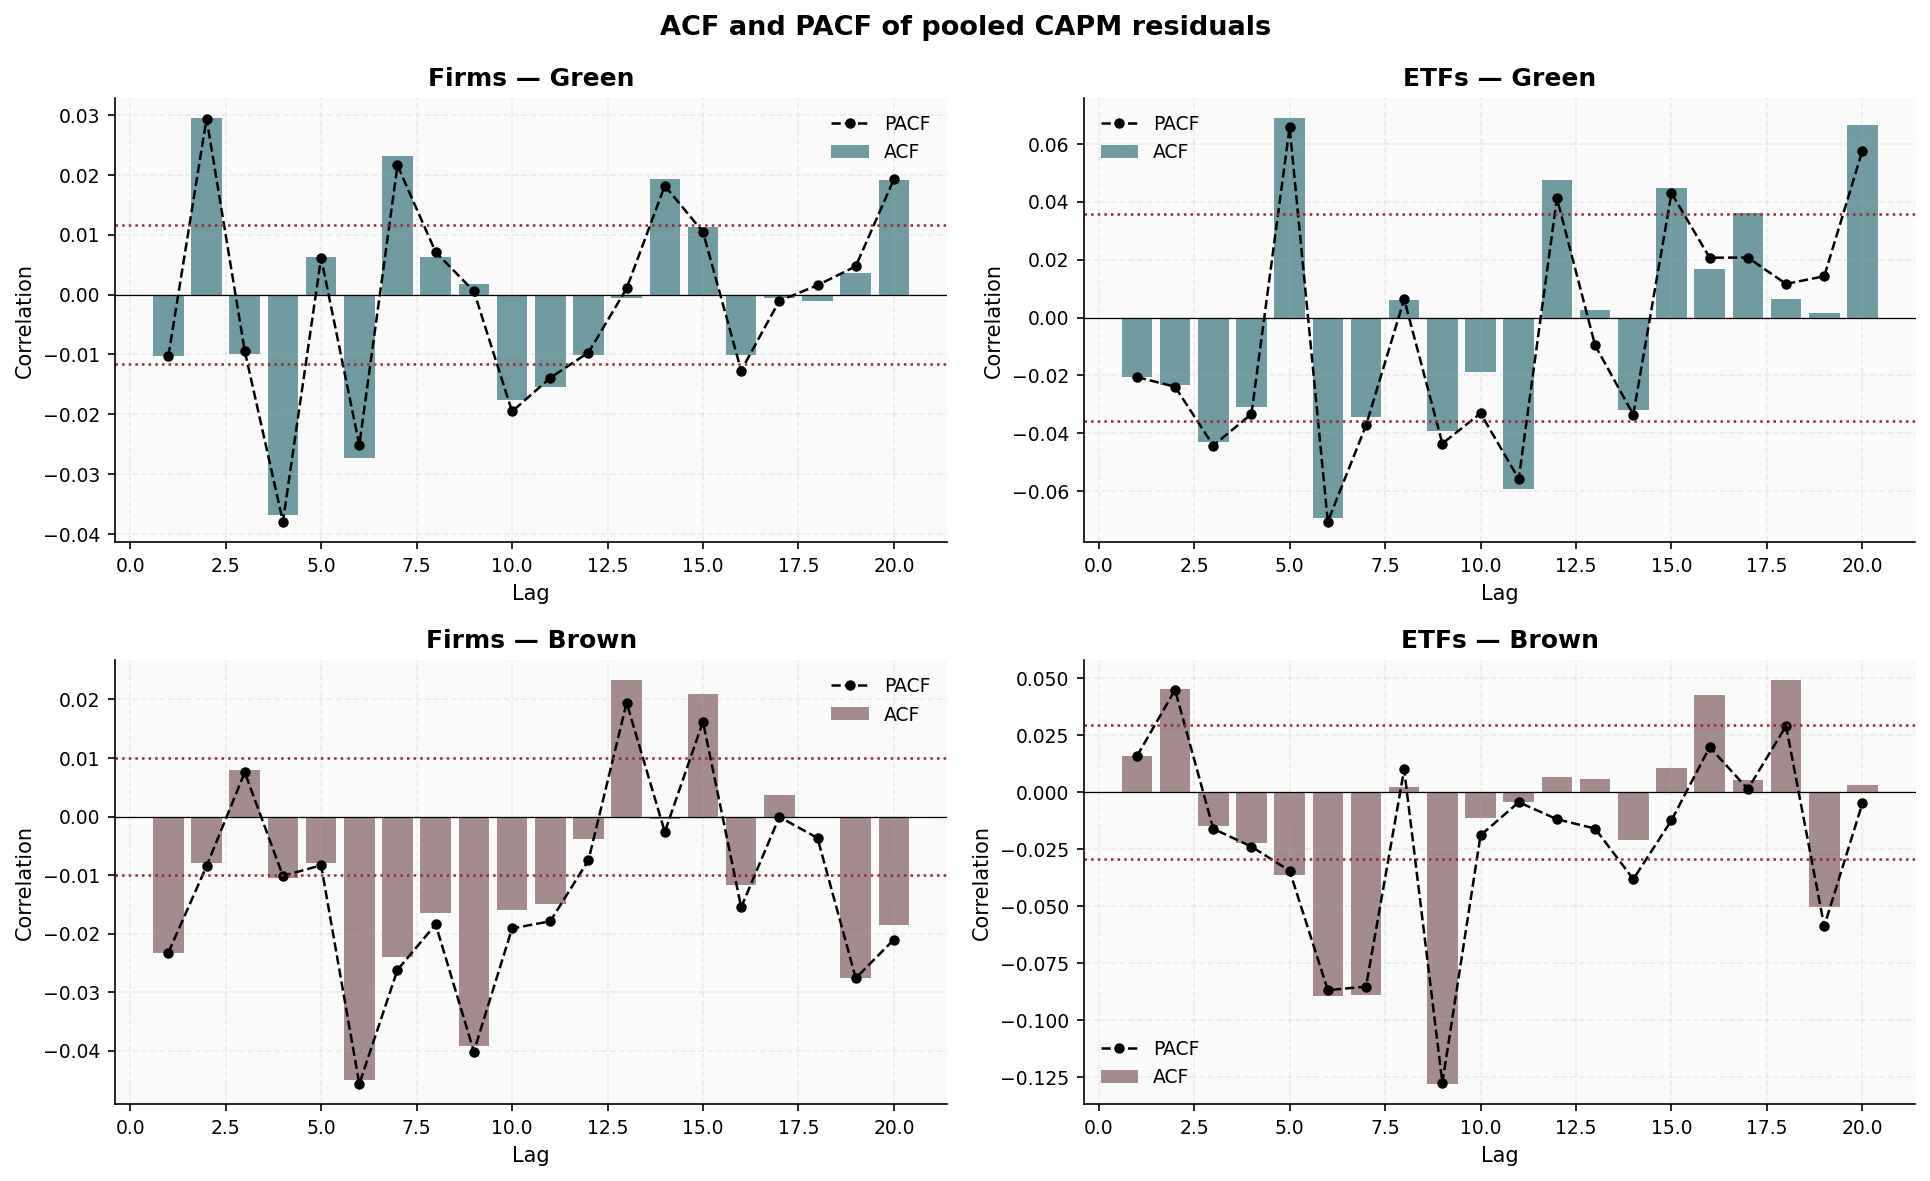

Saved → acf_pacf_capm_residuals.png


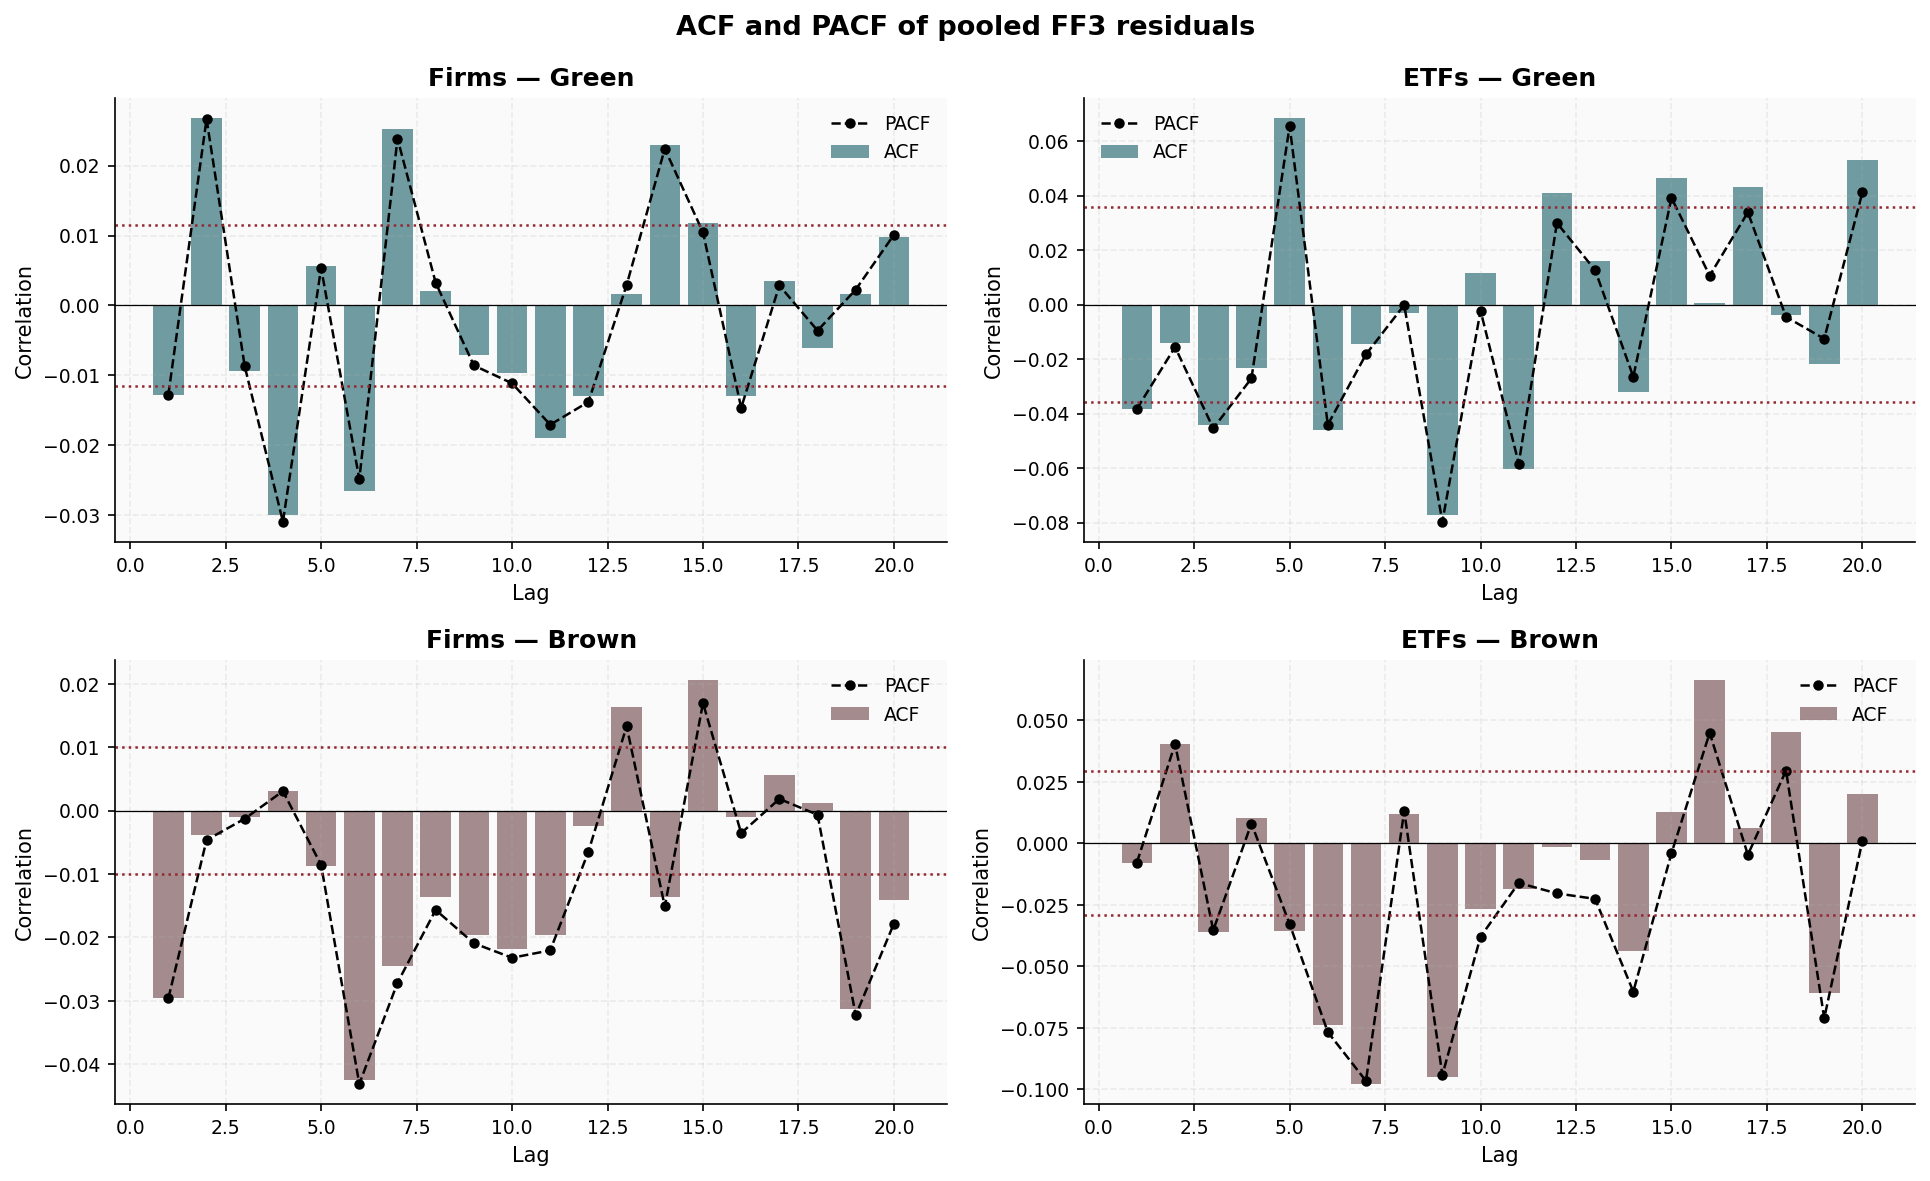

Saved → acf_pacf_ff3_residuals.png


In [72]:
# ── Diagnostic table ─────────────────────────────────────────────────
diag_rows = []
for label, panel, params, group_col in [
    ("Firms", firm_panel_sig, firm_params, "energy_type"),
    ("ETFs",  etf_panel_sig,  etf_params,  "asset_group"),
]:
    for model in ["CAPM", "FF3"]:
        for ric, p in params[model].items():
            if ric not in set(panel["ric"]) or len(p["resid"]) < 20:
                continue
            resid = p["resid"]
            jb    = jarque_bera(resid)
            lb    = acf(resid, nlags=10, fft=False)
            q, qp = q_stat(lb[1:], len(resid))
            try:
                _, arch_p, _, _ = het_arch(resid, nlags=5)
            except Exception:
                arch_p = np.nan
            diag_rows.append({
                "Universe": label, "Model": model,
                "Group": p["group"], "RIC": ric, "N": len(resid),
                "JB p":      jb.pvalue,
                "LjungBox p": qp[-1],
                "DW":         durbin_watson(resid),
                "ARCH p":     arch_p,
            })

diag_table = pd.DataFrame(diag_rows)
diag_summary = (
    diag_table.groupby(["Universe","Model","Group"])
    .agg(N_assets=("RIC","nunique"),
         Med_JB_p=("JB p","median"),
         Med_LB_p=("LjungBox p","median"),
         Mean_DW=("DW","mean"),
         Med_ARCH_p=("ARCH p","median"))
    .reset_index()
)
print("Residual diagnostic summary (CAPM and FF3):")
display(diag_summary.round(4))

# ── ACF/PACF — one figure per model ──────────────────────────────────
for model in ["CAPM", "FF3"]:
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle(f"ACF and PACF of pooled {model} residuals",
                 fontsize=13, fontweight="bold")

    for col_idx, (label, params) in enumerate(
        [("Firms", firm_params), ("ETFs", etf_params)]
    ):
        for row_idx, group in enumerate(["green", "brown"]):
            pool = np.concatenate(
                [p["resid"] for p in params[model].values()
                 if p["group"] == group and len(p["resid"]) > 0]
            )
            color = GREEN if group == "green" else BROWN
            ax    = axes[row_idx, col_idx]

            if len(pool) > 20:
                acf_v  = acf(pool,  nlags=20, fft=False)
                pacf_v = pacf(pool, nlags=20, method="yw")
                ci     = 1.96 / np.sqrt(len(pool))
                ax.bar(range(1, 21), acf_v[1:],   color=color, alpha=0.60, label="ACF")
                ax.plot(range(1, 21), pacf_v[1:], "o--", color="black",
                        ms=4, lw=1.2, label="PACF")
                ax.axhline(+ci, color="#932832", ls=":", lw=1.2)
                ax.axhline(-ci, color="#932832", ls=":", lw=1.2)

            ax.axhline(0, color="black", lw=0.6)
            ax.set_title(f"{label} — {group.capitalize()}")
            ax.set_xlabel("Lag")
            ax.set_ylabel("Correlation")
            ax.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(FIG_DIR / f"acf_pacf_{model.lower()}_residuals.png",
                dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved → acf_pacf_{model.lower()}_residuals.png")

### Standard Error, Confidence Interval, and t-Statistic for Cumulative Abnormal Returns

**Asset-level CAR**

$$
\text{CAR}_i[t_1, t_2] = \sum_{t=t_1}^{t_2} \widehat{AR}_{i,t},
\qquad
\widehat{AR}_{i,t} = (r_{i,t} - r_{f,t}) - \hat{\alpha}_i
  - \sum_{k:\, p_{ik} < 0.10} \hat{\lambda}_{ik} F_{k,t}
$$

where $F_{k,t}$ denotes the $k$-th factor (market excess return, SMB, HML, or PC).

**Equal-weighted group CAR and standard error**

$$
\overline{\text{CAR}}_{\text{EW}} = \frac{1}{N} \sum_{i=1}^N \text{CAR}_i,
\qquad
\widehat{SE}_{\text{EW}} = \frac{s}{\sqrt{N}},
\quad s^2 = \frac{1}{N-1}\sum_{i=1}^N (\text{CAR}_i - \overline{\text{CAR}}_{\text{EW}})^2
$$

**Value-weighted group CAR and standard error**

$$
\widetilde{\text{CAR}}_{\text{VW}} = \sum_{i=1}^N w_i\, \text{CAR}_i,
\quad w_i = \frac{\text{mcap}_i^{\,\text{pre}}}{\sum_j \text{mcap}_j^{\,\text{pre}}},
\qquad
\widehat{SE}_{\text{VW}} = \sqrt{\sum_{i=1}^N w_i^2\,(\text{CAR}_i - \widetilde{\text{CAR}}_{\text{VW}})^2}
$$

**t-statistic and 95% confidence interval**

$$
t = \frac{\overline{\text{CAR}}}{\widehat{SE}},
\qquad
\text{CI}_{95\%} = \overline{\text{CAR}} \pm 1.96 \times \widehat{SE}
$$

One-sided p-values are reported for green assets (H₁: CAR > 0); two-sided for brown.

### Abnormal Returns

Expected returns use only statistically significant factor loadings (`p < 0.10`);
insignificant loadings are set to zero. This is applied consistently across all models
and both universes.

In [73]:
def expected_return(row, p, factor_map, sig_only=True):
    hat = p["b"]["alpha"]
    for col, pname in factor_map.items():
        if pname not in p["b"]:
            continue
        if sig_only and p["p"].get(pname, 1.0) >= BETA_SIG_LEVEL:
            continue
        hat += p["b"][pname] * row[col]
    return hat

ar_specs = {
    "AR_capm":      ("CAPM",         {"Mkt_RF": "Mkt"}),
    "AR_ff3":       ("FF3",          {"Mkt_RF": "Mkt", "SMB": "SMB", "HML": "HML"}),
    "AR_capm_bvol": ("CAPM+BrentVol",{"Mkt_RF": "Mkt", "brent_parkinson_vol": "BrentVol"}),
    "AR_ff3_bvol":  ("FF3+BrentVol", {"Mkt_RF": "Mkt", "SMB": "SMB", "HML": "HML",
                                       "brent_parkinson_vol": "BrentVol"}),
    "AR_capm_ovx":  ("CAPM+OVX",     {"Mkt_RF": "Mkt", "ovx_close": "OVX"}),
    "AR_ff3_ovx":   ("FF3+OVX",      {"Mkt_RF": "Mkt", "SMB": "SMB", "HML": "HML",
                                       "ovx_close": "OVX"}),
}
if "WTIVol" in [p for _, names in model_specs.values() for p in names]:
    ar_specs["AR_capm_wtivol"] = ("CAPM+WTIVol",
                                   {"Mkt_RF":"Mkt","wti_parkinson_vol":"WTIVol"})
    ar_specs["AR_ff3_wtivol"]  = ("FF3+WTIVol",
                                   {"Mkt_RF":"Mkt","SMB":"SMB","HML":"HML",
                                    "wti_parkinson_vol":"WTIVol"})

firm_ev = firm_panel_sig[firm_panel_sig["t"].between(-MAX_WIN, MAX_WIN)].copy()
etf_ev  = etf_panel_sig[etf_panel_sig["t"].between(-MAX_WIN, MAX_WIN)].copy()

for ev, params, label in [
    (firm_ev, firm_params, "Firms"),
    (etf_ev,  etf_params,  "ETFs"),
]:
    for ar_col, (model, fmap) in ar_specs.items():
        if model not in params:
            continue
        ev[ar_col] = [
            row["excess_ret"] - expected_return(row, params[model][row["ric"]], fmap)
            if row["ric"] in params[model] else np.nan
            for _, row in ev.iterrows()
        ]

print("AR columns computed.")
print("Firm:", [c for c in firm_ev.columns if c.startswith("AR_")])
print("ETF: ", [c for c in etf_ev.columns  if c.startswith("AR_")])

AR columns computed.
Firm: ['AR_capm', 'AR_ff3', 'AR_capm_bvol', 'AR_ff3_bvol', 'AR_capm_ovx', 'AR_ff3_ovx', 'AR_capm_wtivol', 'AR_ff3_wtivol']
ETF:  ['AR_capm', 'AR_ff3', 'AR_capm_bvol', 'AR_ff3_bvol', 'AR_capm_ovx', 'AR_ff3_ovx', 'AR_capm_wtivol', 'AR_ff3_wtivol']


### Cumulative Abnormal Returns

CARs are first accumulated at the asset level. Group-level statistics use both
equal-weighting (EW, tests the average firm) and value-weighting (VW, tests the
market-cap-weighted portfolio). One-sided p-values are reported for green assets
(testing H1: CAR > 0); two-sided for brown.

In [74]:
def preEvent_weights(panel):
    return (
        panel[panel["t"] < 0]
        .dropna(subset=["market_cap"])
        .query("market_cap > 0")
        .sort_values(["ric","t"])
        .groupby("ric").tail(1)[["ric","market_cap"]]
        .rename(columns={"market_cap": "pre_event_mcap"})
    )

firm_weights = preEvent_weights(firm_panel_sig)
etf_weights  = preEvent_weights(etf_panel_sig)

# ── Asset-level CARs with 1% winsorization ───────────────────────────
car_rows = []
for label, ev, group_col, weights in [
    ("Firms", firm_ev, "energy_type", firm_weights),
    ("ETFs",  etf_ev,  "asset_group", etf_weights),
]:
    for ar_col in [c for c in ev.columns if c.startswith("AR_")]:
        model = ar_col.replace("AR_","").replace("_","+").upper()
        for t1, t2 in EVENT_WINDOWS:
            wl  = f"[{t1:+d},{t2:+d}]"
            win = ev[ev["t"].between(t1,t2)].copy()
            tmp = (
                win.dropna(subset=[ar_col])
                   .groupby(["ric",group_col])[ar_col].sum()
                   .reset_index().rename(columns={ar_col:"CAR",group_col:"group"})
            )
            if len(tmp) > 0:
                lo, hi = tmp["CAR"].quantile([0.01, 0.99])
                tmp["CAR"] = tmp["CAR"].clip(lo, hi)
            tmp = tmp.assign(universe=label, model=model, window=wl, ar_col=ar_col)
            car_rows.append(tmp)

asset_cars = pd.concat(car_rows, ignore_index=True)
asset_cars = pd.concat([
    asset_cars[asset_cars["universe"]=="Firms"].merge(firm_weights, on="ric", how="left"),
    asset_cars[asset_cars["universe"]=="ETFs"].merge(etf_weights,  on="ric", how="left"),
], ignore_index=True)

# ── Group-level EW and VW CAR tests ──────────────────────────────────
result_rows = []
for (universe, model, window, group), g0 in asset_cars.groupby(
        ["universe","model","window","group"]):
    g = g0.dropna(subset=["CAR"])
    if len(g) < 2:
        continue

    x  = g["CAR"].values
    n  = len(x)
    m  = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    t_ew  = m / (se + 1e-30)
    result_rows.append({
        "universe":universe,"model":model,"window":window,"group":group,
        "weighting":"EW","n":n,"n_eff":n,
        "mean_CAR%":m*100,"SE%":se*100,
        "t_stat":t_ew,
        "p_two": 2*stats.t.sf(abs(t_ew), df=n-1),
        "p_one": stats.t.sf(t_ew, df=n-1),
    })

    gv = g.dropna(subset=["pre_event_mcap"]).query("pre_event_mcap > 0").copy()
    if len(gv) >= 2:
        gv["w"]   = gv["pre_event_mcap"] / gv["pre_event_mcap"].sum()
        m_vw      = (gv["w"] * gv["CAR"]).sum()
        se_vw     = np.sqrt(((gv["w"]**2) * (gv["CAR"] - m_vw)**2).sum())
        n_eff     = 1 / (gv["w"]**2).sum()
        t_vw      = m_vw / (se_vw + 1e-30)
        result_rows.append({
            "universe":universe,"model":model,"window":window,"group":group,
            "weighting":"VW","n":len(gv),"n_eff":n_eff,
            "mean_CAR%":m_vw*100,"SE%":se_vw*100,
            "t_stat":t_vw,
            "p_two": 2*stats.t.sf(abs(t_vw), df=max(n_eff-1,1)),
            "p_one": stats.t.sf(t_vw, df=max(n_eff-1,1)),
        })

car_results = pd.DataFrame(result_rows)
car_results["sig_one"] = car_results["p_one"].apply(stars)
car_results["sig_two"] = car_results["p_two"].apply(stars)
print(f"car_results shape: {car_results.shape}")
display(car_results.head(10))

car_results shape: (832, 14)


,universe,model,window,group,weighting,n,n_eff,mean_CAR%,SE%,t_stat,p_two,p_one,sig_one,sig_two
0,ETFs,CAPM,"[+0,+10]",brown,EW,17,17.000000,11.105713,2.949465,3.765331,0.001692,0.000846,***,***
1,ETFs,CAPM,"[+0,+10]",brown,VW,17,3.536220,5.907533,0.805743,7.331780,0.009044,0.004522,***,***
2,ETFs,CAPM,"[+0,+10]",green,EW,12,12.000000,1.806721,1.056729,1.709729,0.115338,0.057669,*,
3,ETFs,CAPM,"[+0,+10]",green,VW,12,2.602406,-0.752528,1.663671,-0.452330,0.704734,0.647633,,
4,ETFs,CAPM,"[+0,+15]",brown,EW,17,17.000000,15.062286,2.540589,5.928660,0.000021,0.000011,***,***
5,ETFs,CAPM,"[+0,+15]",brown,VW,17,3.536220,10.087551,1.025602,9.835732,0.004380,0.002190,***,***
6,ETFs,CAPM,"[+0,+15]",green,EW,12,12.000000,1.382332,1.022970,1.351293,0.203738,0.101869,,
7,ETFs,CAPM,"[+0,+15]",green,VW,12,2.602406,-1.240038,1.374255,-0.902335,0.481665,0.759168,,
8,ETFs,CAPM,"[+0,+20]",brown,EW,17,17.000000,22.572309,3.435553,6.570211,0.000006,0.000003,***,***
9,ETFs,CAPM,"[+0,+20]",brown,VW,17,3.536220,16.213116,1.718582,9.434009,0.004858,0.002429,***,***


### H1 report (Firms & ETFs) 

In [75]:
def h1_report(car_results, universe, hyp_label):
    print("\n" + "═"*100)
    print(f"H1 REPORT — {universe.upper()}")
    print(f"Hypothesis: {hyp_label}")
    print("═"*100)

    for model in ["CAPM","FF3"]:
        print(f"\n{model}")
        print("─"*100)
        for window in WIN_LABELS:
            print(f"\n  Window {window}")
            for weighting in ["EW","VW"]:
                for group in ["green","brown"]:
                    row = car_results[
                        (car_results["universe"]==universe) &
                        (car_results["model"]==model) &
                        (car_results["window"]==window) &
                        (car_results["group"]==group) &
                        (car_results["weighting"]==weighting)
                    ]
                    if row.empty: continue
                    r   = row.iloc[0]
                    p   = r["p_two"]
                    if   r["mean_CAR%"] > 0 and p < 0.05:  verdict = "positive & significant at 5%"
                    elif r["mean_CAR%"] < 0 and p < 0.05:  verdict = "negative & significant at 5%"
                    else:                                   verdict = "investigate further"
                    print(
                        f"    {weighting:<2} {group:<5}: "
                        f"CAR={r['mean_CAR%']:>7.2f}%  t={r['t_stat']:>6.2f}  "
                        f"two-sided p={p:>6.3f}  → {verdict}"
                    )

h1_report(car_results, "Firms",
          "Green firms earn significantly positive CARs after the oil shock.")
h1_report(car_results, "ETFs",
          "Green ETFs earn significantly positive CARs after the oil shock.")


════════════════════════════════════════════════════════════════════════════════════════════════════
H1 REPORT — FIRMS
Hypothesis: Green firms earn significantly positive CARs after the oil shock.
════════════════════════════════════════════════════════════════════════════════════════════════════

CAPM
────────────────────────────────────────────────────────────────────────────────────────────────────

  Window [-1,+1]
    EW green: CAR=  -2.84%  t= -4.84  two-sided p= 0.000  → negative & significant at 5%
    EW brown: CAR=   3.84%  t=  9.08  two-sided p= 0.000  → positive & significant at 5%
    VW green: CAR=  -0.96%  t= -2.51  two-sided p= 0.126  → investigate further
    VW brown: CAR=   3.83%  t=  7.98  two-sided p= 0.000  → positive & significant at 5%

  Window [-3,+3]
    EW green: CAR=  -3.16%  t= -2.63  two-sided p= 0.010  → negative & significant at 5%
    EW brown: CAR=   4.67%  t=  6.48  two-sided p= 0.000  → positive & significant at 5%
    VW green: CAR=  -0.24%  t= -0

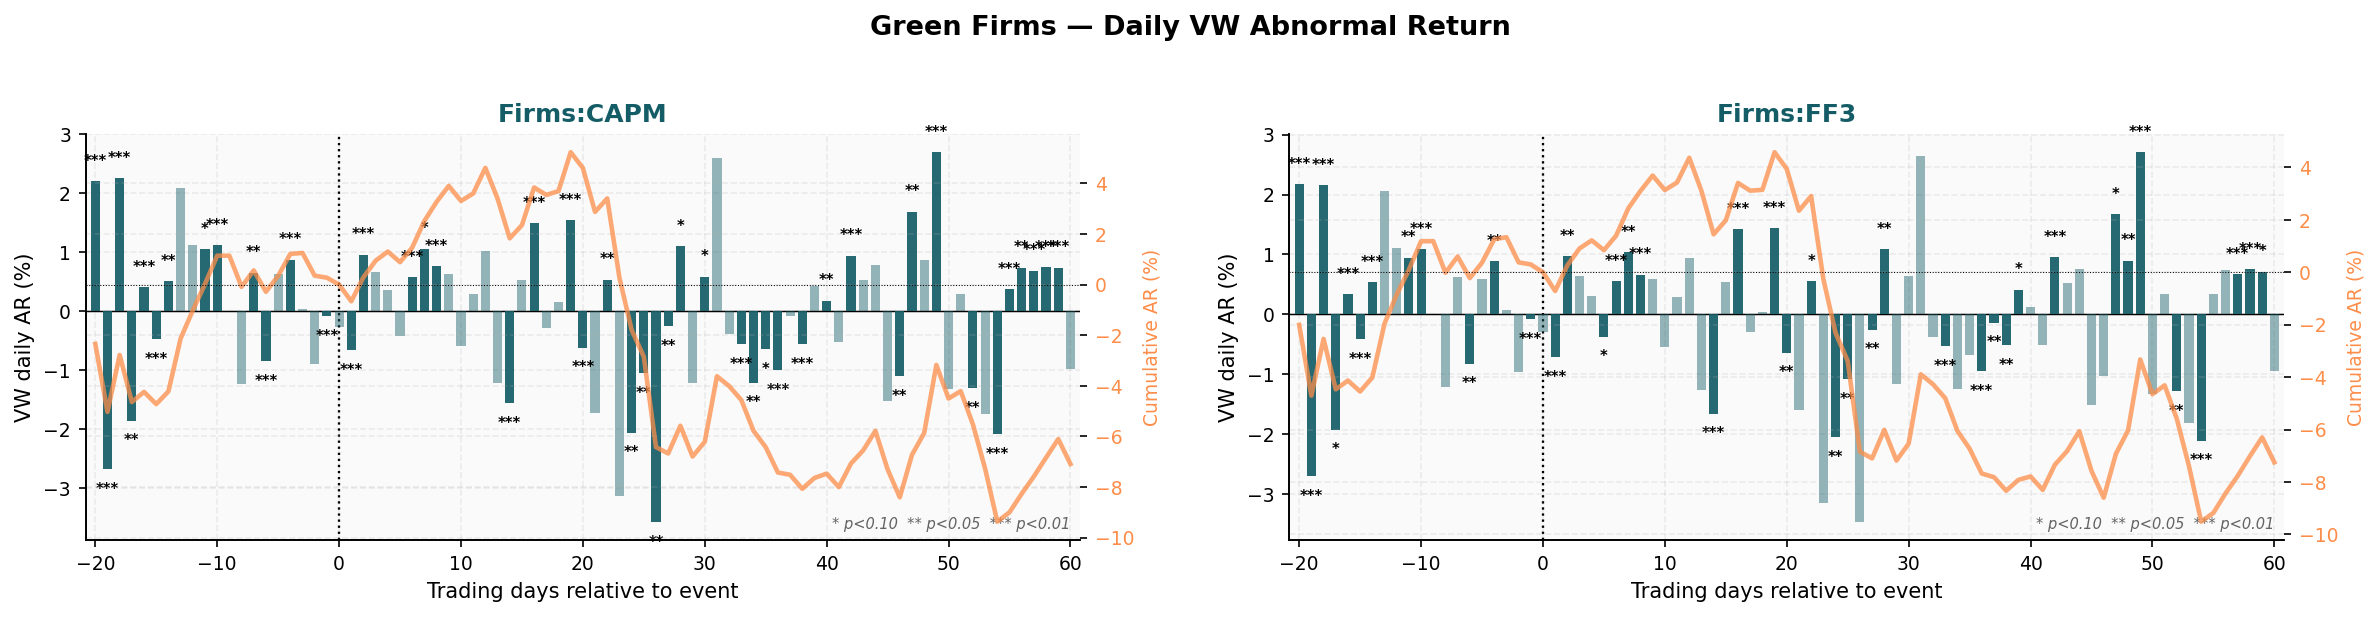

Saved → daily_AR_bar_firms_Green_CAPM_FF3.png


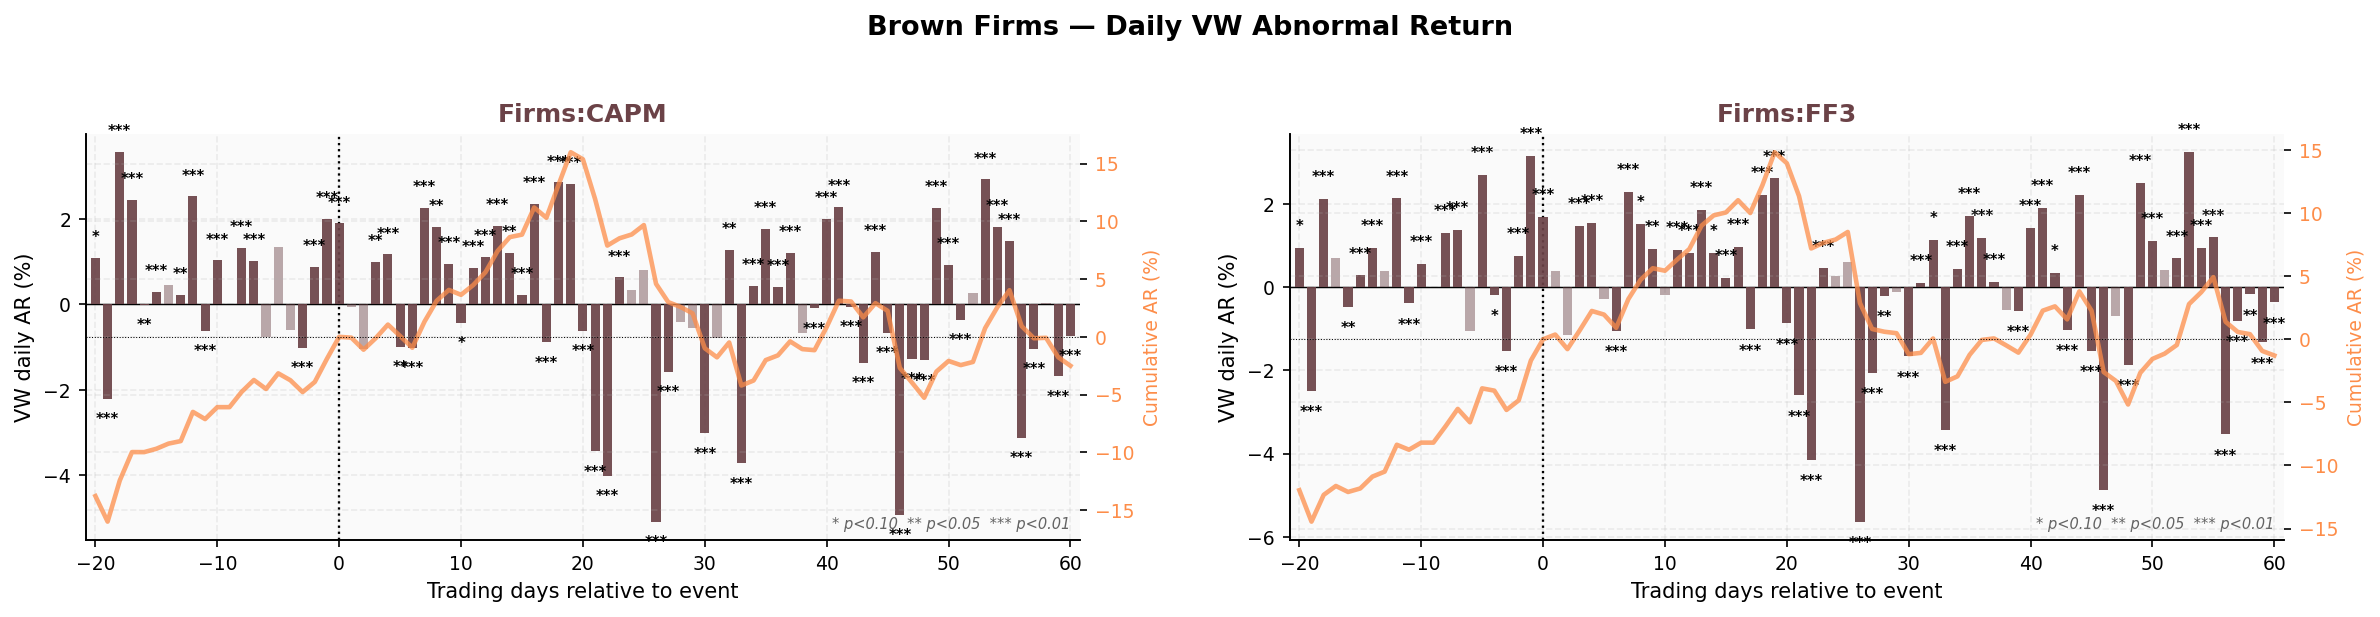

Saved → daily_AR_bar_firms_Brown_CAPM_FF3.png


In [76]:
ar_model_list = [("AR_capm", "Firms:CAPM"), ("AR_ff3", "Firms:FF3")]

for group in ["green", "brown"]:
    color       = GREEN if group == "green" else BROWN
    group_label = "Green" if group == "green" else "Brown"
    fname       = f"daily_AR_bar_firms_{group_label}_CAPM_FF3.png"

    fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=False)
    fig.suptitle(f"{group_label} Firms — Daily VW Abnormal Return",
                 fontsize=13, fontweight="bold", y=1.02)

    for ax, (ar_col, model_label) in zip(axes, ar_model_list):
        if ar_col not in firm_ev.columns:
            ax.set_visible(False)
            continue

        ev = (firm_ev[(firm_ev["energy_type"] == group) &
                      firm_ev["t"].between(PLOT_START, PLOT_END)]
              .copy().merge(firm_weights, on="ric", how="left"))

        t_vals, ar_vals, star_vals = [], [], []
        for t in range(PLOT_START, PLOT_END + 1):
            day = ev[ev["t"] == t].dropna(subset=[ar_col, "pre_event_mcap"])
            day = day[day["pre_event_mcap"] > 0]
            if len(day) > 1:
                day = day.copy()
                day["w"] = day["pre_event_mcap"] / day["pre_event_mcap"].sum()
                ar_vw    = (day["w"] * day[ar_col]).sum()
                _, p_val = stats.ttest_1samp(day[ar_col].dropna(), 0)
            elif len(day) == 1:
                ar_vw, p_val = day[ar_col].iloc[0], 1.0
            else:
                ar_vw, p_val = 0.0, 1.0
            t_vals.append(t)
            ar_vals.append(ar_vw * 100)
            star_vals.append(stars(p_val))

        bar_alpha = [0.45 if s == "" else 0.92 for s in star_vals]
        bars = ax.bar(t_vals, ar_vals, width=0.75, color=color, zorder=3)
        for b, a in zip(bars, bar_alpha):
            b.set_alpha(a)

        yr = max(abs(v) for v in ar_vals) if ar_vals else 1
        for t, v, s in zip(t_vals, ar_vals, star_vals):
            if s:
                y_pos = v + yr * 0.06 if v >= 0 else v - yr * 0.06
                ax.text(t, y_pos, s, ha="center",
                        va="bottom" if v >= 0 else "top",
                        fontsize=7, fontweight="bold")

        cum_full = np.cumsum(ar_vals)
        t0_idx   = t_vals.index(0)
        cum      = [v - cum_full[t0_idx] for v in cum_full]
        ax2 = ax.twinx()
        ax2.plot(t_vals, cum, color="#fd8d49", lw=2.2, ls="-", alpha=0.75,
                 label="Cumulative AR")
        ax2.axhline(0, color="black", lw=0.5, ls=":")
        ax2.set_ylabel("Cumulative AR (%)", color="#fd8d49", fontsize=9)
        ax2.tick_params(axis="y", labelcolor="#fd8d49")
        ax2.spines["right"].set_edgecolor("#fd8d49")

        ax.axhline(0, color="black", lw=0.7)
        ax.axvline(0, color="black", lw=1.1, ls=":")
        ax.set_xlim(PLOT_START - 0.8, PLOT_END + 0.8)
        ax.set_xlabel("Trading days relative to event")
        ax.set_ylabel("VW daily AR (%)")
        ax.set_title(model_label, color=color, fontweight="semibold")
        ax.annotate("* p<0.10  ** p<0.05  *** p<0.01",
                    xy=(0.99, 0.02), xycoords="axes fraction",
                    ha="right", va="bottom", fontsize=7, color=GREY, style="italic")

    plt.tight_layout(w_pad=2.5)
    plt.savefig(FIG_DIR / fname, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")

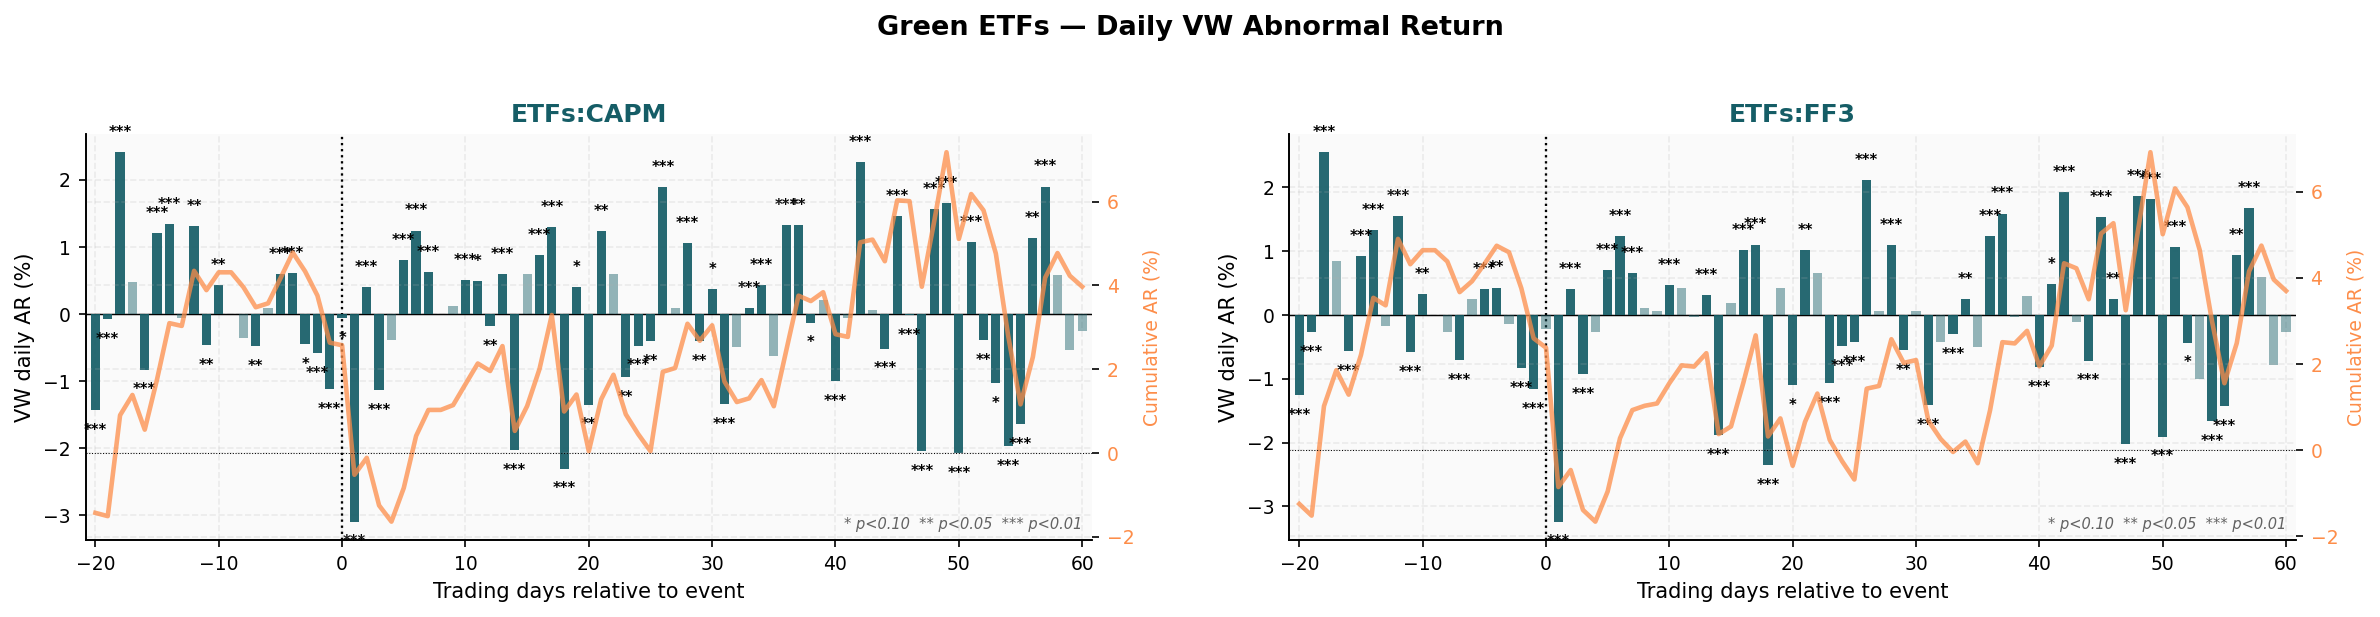

Saved → daily_AR_bar_etfs_Green_CAPM_FF3.png


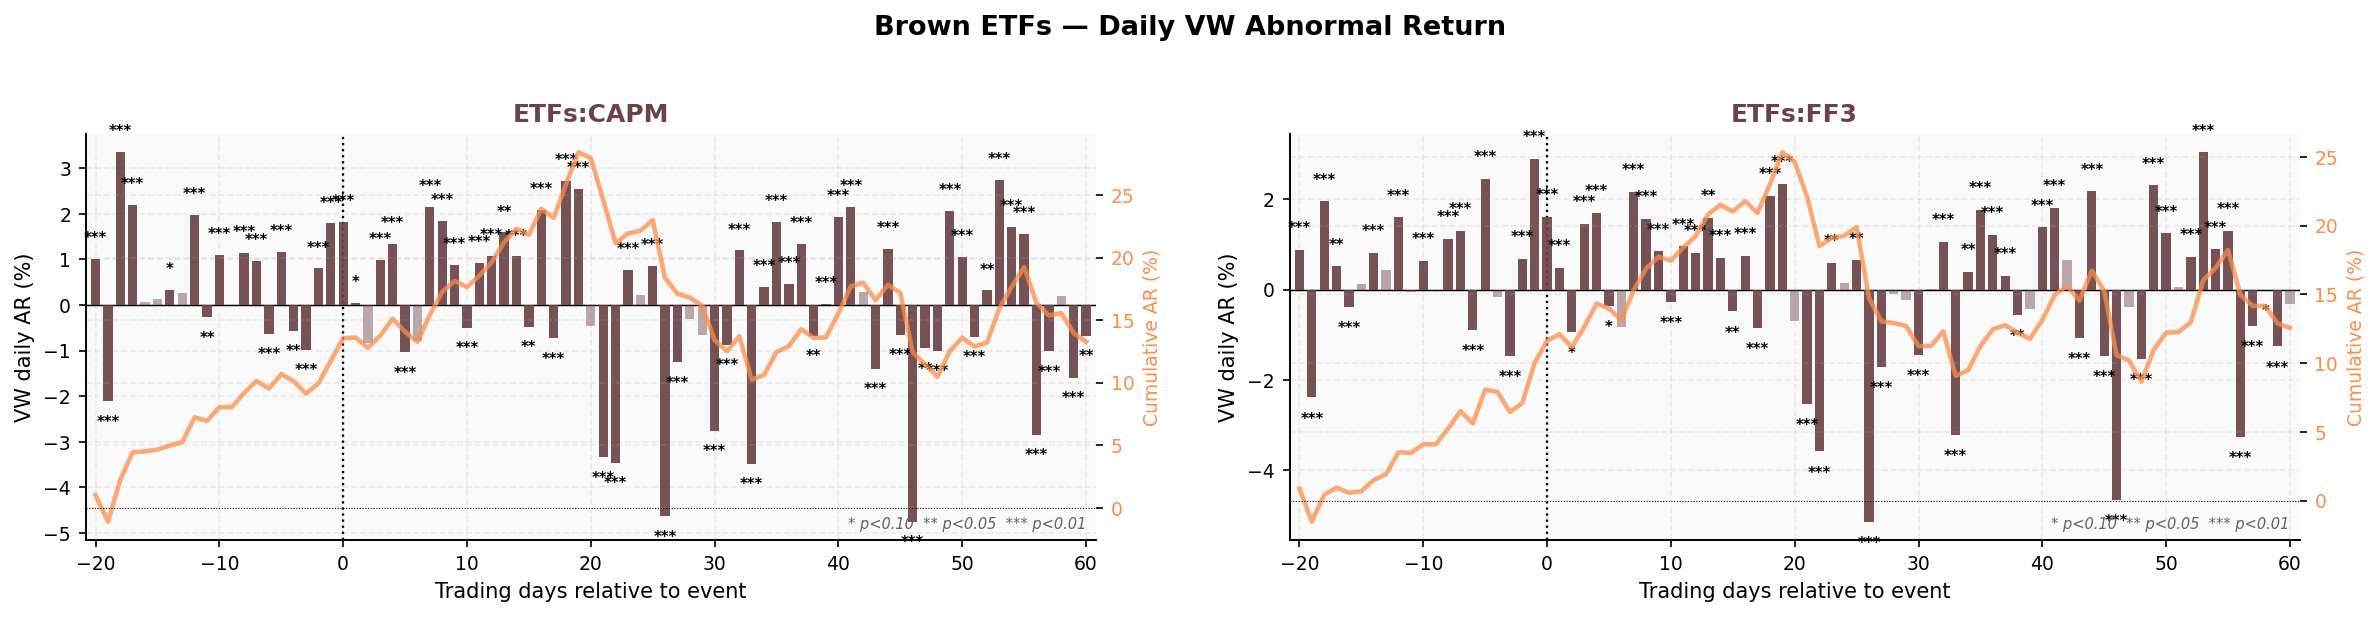

Saved → daily_AR_bar_etfs_Brown_CAPM_FF3.png


In [77]:
ar_model_list = [("AR_capm", "ETFs:CAPM"), ("AR_ff3", "ETFs:FF3")]

for group in ["green", "brown"]:
    color       = GREEN if group == "green" else BROWN
    group_label = "Green" if group == "green" else "Brown"
    fname       = f"daily_AR_bar_etfs_{group_label}_CAPM_FF3.png"

    fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=False)
    fig.suptitle(f"{group_label} ETFs — Daily VW Abnormal Return",
                 fontsize=13, fontweight="bold", y=1.02)

    for ax, (ar_col, model_label) in zip(axes, ar_model_list):
        if ar_col not in etf_ev.columns:
            ax.set_visible(False)
            continue

        ev = (etf_ev[(etf_ev["asset_group"] == group) &
                      etf_ev["t"].between(PLOT_START, PLOT_END)]
              .copy().merge(etf_weights, on="ric", how="left"))

        t_vals, ar_vals, star_vals = [], [], []
        for t in range(PLOT_START, PLOT_END + 1):
            day = ev[ev["t"] == t].dropna(subset=[ar_col, "pre_event_mcap"])
            day = day[day["pre_event_mcap"] > 0]
            if len(day) > 1:
                day = day.copy()
                day["w"] = day["pre_event_mcap"] / day["pre_event_mcap"].sum()
                ar_vw    = (day["w"] * day[ar_col]).sum()
                _, p_val = stats.ttest_1samp(day[ar_col].dropna(), 0)
            elif len(day) == 1:
                ar_vw, p_val = day[ar_col].iloc[0], 1.0
            else:
                ar_vw, p_val = 0.0, 1.0
            t_vals.append(t)
            ar_vals.append(ar_vw * 100)
            star_vals.append(stars(p_val))

        bar_alpha = [0.45 if s == "" else 0.92 for s in star_vals]
        bars = ax.bar(t_vals, ar_vals, width=0.75, color=color, zorder=3)
        for b, a in zip(bars, bar_alpha):
            b.set_alpha(a)

        yr = max(abs(v) for v in ar_vals) if ar_vals else 1
        for t, v, s in zip(t_vals, ar_vals, star_vals):
            if s:
                y_pos = v + yr * 0.06 if v >= 0 else v - yr * 0.06
                ax.text(t, y_pos, s, ha="center",
                        va="bottom" if v >= 0 else "top",
                        fontsize=7, fontweight="bold")

        cum = np.cumsum(ar_vals)
        ax2 = ax.twinx()
        ax2.plot(t_vals, cum, color="#fd8d49", lw=2.2, ls="-", alpha=0.75,
                 label="Cumulative AR")
        ax2.axhline(0, color="black", lw=0.5, ls=":")
        ax2.set_ylabel("Cumulative AR (%)", color="#fd8d49", fontsize=9)
        ax2.tick_params(axis="y", labelcolor="#fd8d49")
        ax2.spines["right"].set_edgecolor("#fd8d49")

        ax.axhline(0, color="black", lw=0.7)
        ax.axvline(0, color="black", lw=1.1, ls=":")
        ax.set_xlim(PLOT_START - 0.8, PLOT_END + 0.8)
        ax.set_xlabel("Trading days relative to event")
        ax.set_ylabel("VW daily AR (%)")
        ax.set_title(model_label, color=color, fontweight="semibold")
        ax.annotate("* p<0.10  ** p<0.05  *** p<0.01",
                    xy=(0.99, 0.02), xycoords="axes fraction",
                    ha="right", va="bottom", fontsize=7, color=GREY, style="italic")

    plt.tight_layout(w_pad=2.5)
    plt.savefig(FIG_DIR / fname, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")

### Sector Analysis

Company names are used to assign each firm a clean-energy or fossil-fuel subsector.
CARs are averaged within each subsector over the `[−1,+1]` and `[0,+10]` windows.
Each window and group is displayed as a separate figure so that subsector rankings
are legible at full page width.

In [78]:
# ── Precise manual sector mapping ─────────────────────────────────────
SECTOR_MAP = {
    # ── GREEN ──────────────────────────────────────────────────────
    "ARRY.O":"Solar","CSIQ.O":"Solar","DQ.N":"Solar","ENPH.O":"Solar",
    "FSLR.O":"Solar","FTCI.O":"Solar","JKS.N":"Solar","NXT.O":"Solar",
    "SEDG.O":"Solar","SHLS.O":"Solar","SPWR.O":"Solar","RUN.O":"Solar",
    "SPRU.N":"Solar","BNRG.OQ":"Solar",
    "AMSC.O":"Wind","BWEN.O":"Wind",
    "TSLA.O":"EV & Mobility","LCID.O":"EV & Mobility","RIVN.O":"EV & Mobility",
    "NIO.N":"EV & Mobility","XPEV.N":"EV & Mobility","PSNY.O":"EV & Mobility",
    "WKHS.O":"EV & Mobility","GP.O":"EV & Mobility","NIU.O":"EV & Mobility",
    "CENN.O":"EV & Mobility","REE.O":"EV & Mobility","ACHR.N":"EV & Mobility",
    "JOBY.N":"EV & Mobility",
    "BLNK.O":"EV Charging","CHPT.N":"EV Charging",
    "EVGO.O":"EV Charging","NAAS.OQ":"EV Charging",
    "ADSE.O":"Battery & Storage","AMPX.N":"Battery & Storage",
    "BEEM.O":"Battery & Storage","ENVX.O":"Battery & Storage",
    "EOSE.O":"Battery & Storage","FLNC.O":"Battery & Storage",
    "GWH.N":"Battery & Storage","MVST.O":"Battery & Storage",
    "NRGV.N":"Battery & Storage","SLDP.O":"Battery & Storage","STEM.N":"Battery & Storage",
    "BLDP.O":"Hydrogen & Fuel Cells","BE.N":"Hydrogen & Fuel Cells",
    "FCEL.O":"Hydrogen & Fuel Cells","HTOO.O":"Hydrogen & Fuel Cells","PLUG.O":"Hydrogen & Fuel Cells",
    "CEG.OQ":"Nuclear","OKLO.N":"Nuclear","SMR.N":"Nuclear",
    "ALB.N":"Lithium & Minerals","LAC.N":"Lithium & Minerals",
    "SGML.O":"Lithium & Minerals","SLI.A":"Lithium & Minerals","SQM.N":"Lithium & Minerals",
    "AMTX.O":"Biofuels & RNG","FF.N":"Biofuels & RNG","GEVO.O":"Biofuels & RNG",
    "GPRE.OQ":"Biofuels & RNG","LNZA.O":"Biofuels & RNG","MNTK.O":"Biofuels & RNG",
    "OPAL.O":"Biofuels & RNG","REX.N":"Biofuels & RNG","VGAS.OQ":"Biofuels & RNG",
    "ORA.N":"Geothermal",
}

name_map = (
    firm_panel_sig[["ric","company_name","energy_type"]]
    .drop_duplicates("ric").copy()
)
name_map["subsector"] = name_map["ric"].map(SECTOR_MAP).fillna("Other")

firm_panel_sec = firm_panel_sig.merge(name_map[["ric","subsector"]], on="ric", how="left")
firm_ev_sec    = firm_ev.merge(name_map[["ric","subsector"]], on="ric", how="left")

# ── Sector-level CAR summary ──────────────────────────────────────────
sector_ev_cars = firm_ev_sec.merge(firm_weights, on="ric", how="left")
sector_summary_rows = []
for (subsector, energy_type), grp in sector_ev_cars.groupby(
        [name_map.set_index("ric")["subsector"].reindex(sector_ev_cars["ric"]).values,
         sector_ev_cars["energy_type"]]
):
    if subsector in ("Other",):
        continue
    for t1, t2 in [(-1, 1), (0, 10)]:
        wl  = f"[{t1:+d},{t2:+d}]"
        win = grp[grp["t"].between(t1, t2)]
        asset_car = win.groupby("ric")["AR_ff3"].sum().reset_index()
        if len(asset_car) >= 1:
            sector_summary_rows.append({
                "subsector": subsector, "energy_type": energy_type,
                "window": wl, "n": len(asset_car),
                "mean_CAR": asset_car["AR_ff3"].mean() * 100,
            })

sector_summary = pd.DataFrame(sector_summary_rows)
print(sector_summary.head(12))

                subsector energy_type    window   n   mean_CAR
0       Battery & Storage       green   [-1,+1]  10  -9.967917
1       Battery & Storage       green  [+0,+10]  10   9.316708
2          Biofuels & RNG       green   [-1,+1]   9   1.440254
3          Biofuels & RNG       green  [+0,+10]   9  28.955004
4           EV & Mobility       green   [-1,+1]  12  -3.483092
5           EV & Mobility       green  [+0,+10]  12   4.115998
6             EV Charging       green   [-1,+1]   4  -3.455023
7             EV Charging       green  [+0,+10]   4  -1.843138
8              Geothermal       green   [-1,+1]   1   0.109215
9              Geothermal       green  [+0,+10]   1   5.815028
10  Hydrogen & Fuel Cells       green   [-1,+1]   4  -3.407550
11  Hydrogen & Fuel Cells       green  [+0,+10]   4   8.944600


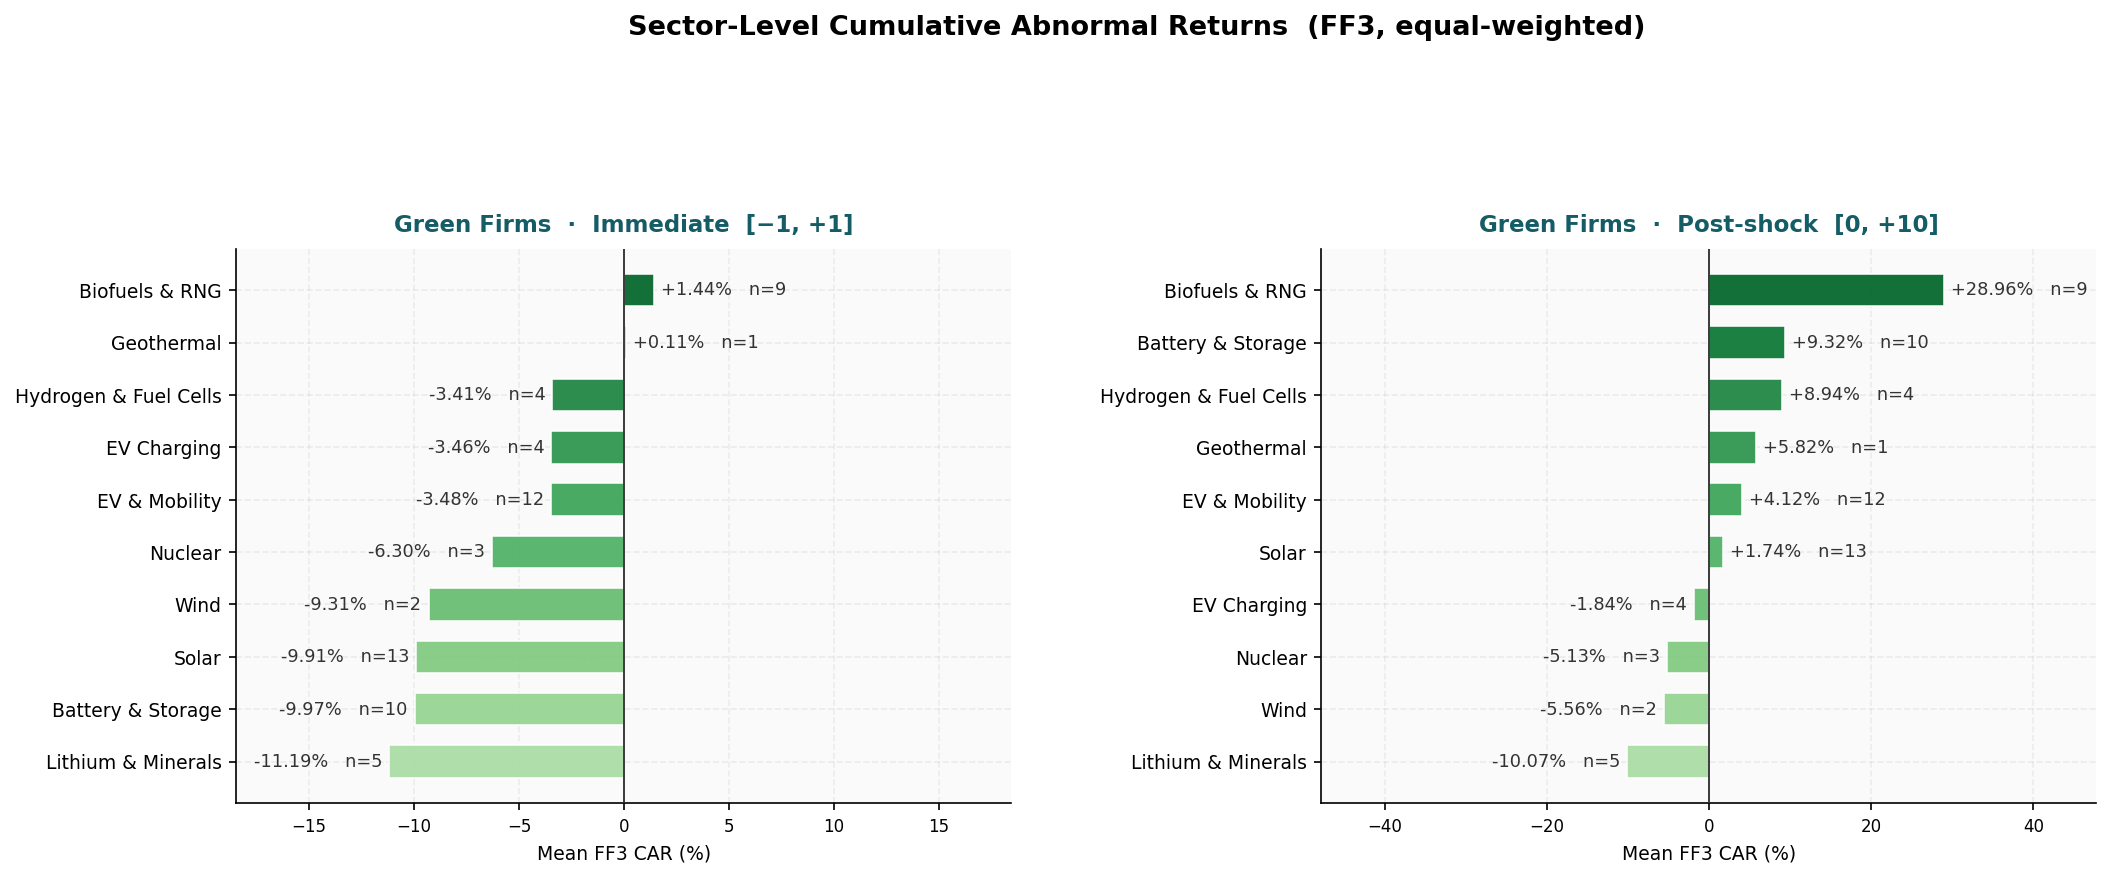

In [79]:
import matplotlib.cm as cm

fig, axes = plt.subplots(2, 2, figsize=(16, 12),
                          gridspec_kw={"hspace": 0.50, "wspace": 0.40})

windows     = ["[-1,+1]", "[+0,+10]"]
win_titles  = {"[-1,+1]": "Immediate  [−1, +1]", "[+0,+10]": "Post-shock  [0, +10]"}
group_labels = {"green": "Green Firms", "brown": "Brown Firms"}
group_cmaps  = {"green": cm.get_cmap("Greens"), "brown": cm.get_cmap("YlOrBr")}
group_colors = {"green": GREEN, "brown": BROWN}

for row_idx, group in enumerate(["green", "brown"]):
    for col_idx, window in enumerate(windows):
        ax  = axes[row_idx, col_idx]

        sub = (
            sector_summary[
                (sector_summary["energy_type"] == group) &
                (sector_summary["window"] == window)
            ]
            .sort_values("mean_CAR", ascending=True)
            .reset_index(drop=True)
        )

        if sub.empty:
            ax.set_visible(False)
            continue

        n_bars = len(sub)
        cmap   = group_cmaps[group]
        colors = [cmap(0.35 + 0.55 * i / max(n_bars - 1, 1)) for i in range(n_bars)]

        bars = ax.barh(
            sub["subsector"], sub["mean_CAR"],
            color=colors, edgecolor="white", linewidth=0.8,
            height=0.62, alpha=0.92, zorder=3
        )

        # Inline value + n label
        x_range = sub["mean_CAR"].abs().max()
        offset  = x_range * 0.03

        for bar, (_, row) in zip(bars, sub.iterrows()):
            x  = bar.get_width()
            ha = "left" if x >= 0 else "right"
            ax.text(
                x + (offset if x >= 0 else -offset),
                bar.get_y() + bar.get_height() / 2,
                f"{x:+.2f}%   n={int(row['n'])}",
                va="center", ha=ha, fontsize=8.5, color="#333333"
            )

        ax.axvline(0, color="#333333", lw=0.9, zorder=4)
        ax.set_xlim(-(x_range * 1.65), x_range * 1.65)
        ax.set_xlabel("Mean FF3 CAR (%)", fontsize=9)
        ax.set_title(
            f"{group_labels[group]}  ·  {win_titles[window]}",
            color=group_colors[group], fontweight="semibold", fontsize=11, pad=8
        )
        ax.tick_params(axis="y", labelsize=9)
        ax.tick_params(axis="x", labelsize=8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_axisbelow(True)
        ax.grid(axis="x", alpha=0.18, linestyle="--")

plt.suptitle(
    "Sector-Level Cumulative Abnormal Returns  (FF3, equal-weighted)",
    fontsize=13, fontweight="bold", y=1.01
)
plt.savefig(FIG_DIR / "sector_CAR_barh_clean.png", dpi=200, bbox_inches="tight")
plt.show()

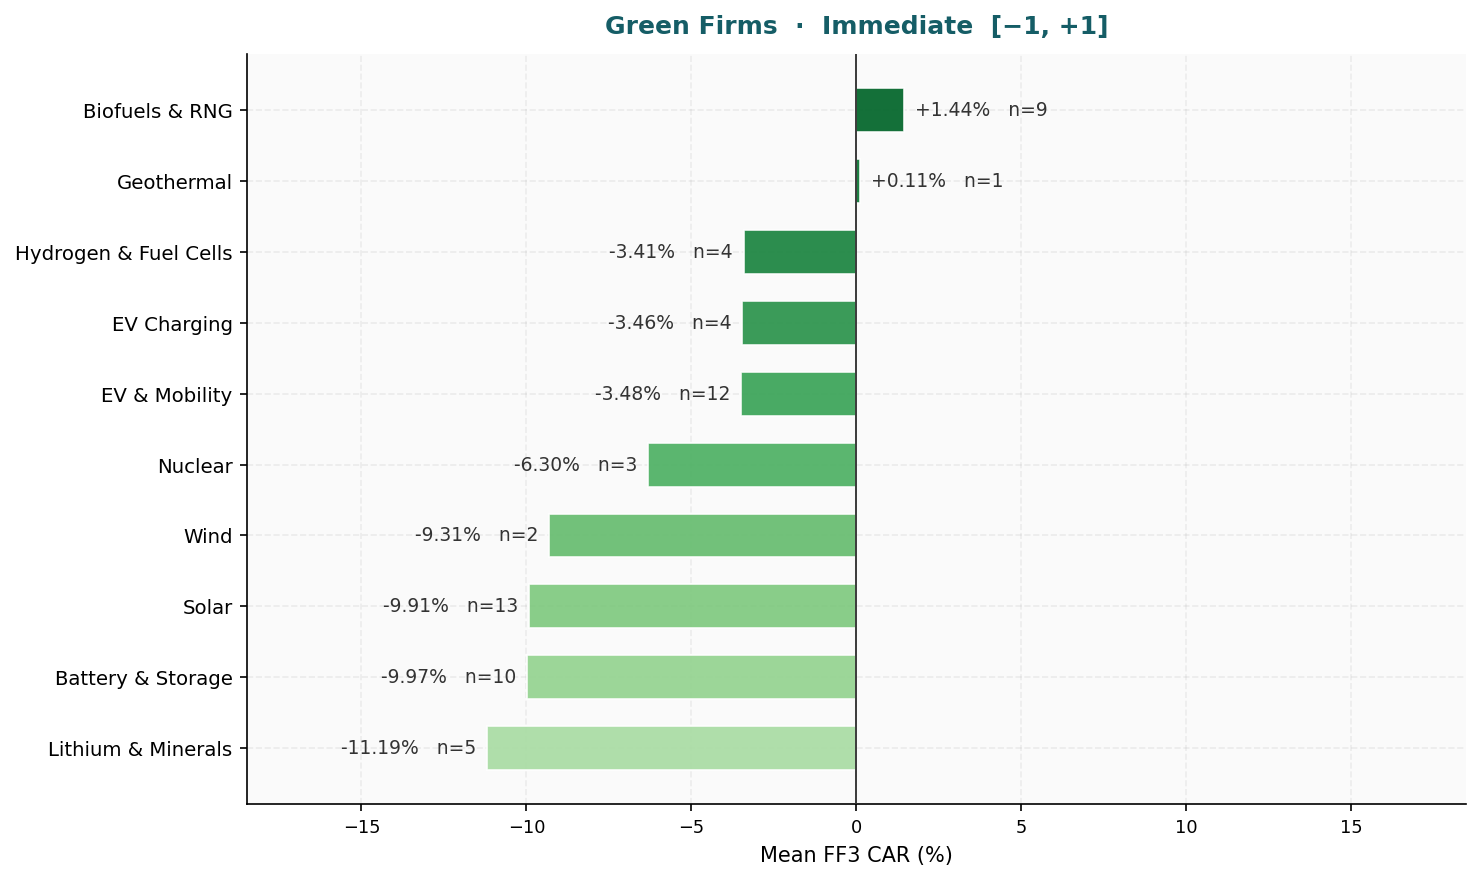

Saved → sector_CAR_green_-1_p1.png


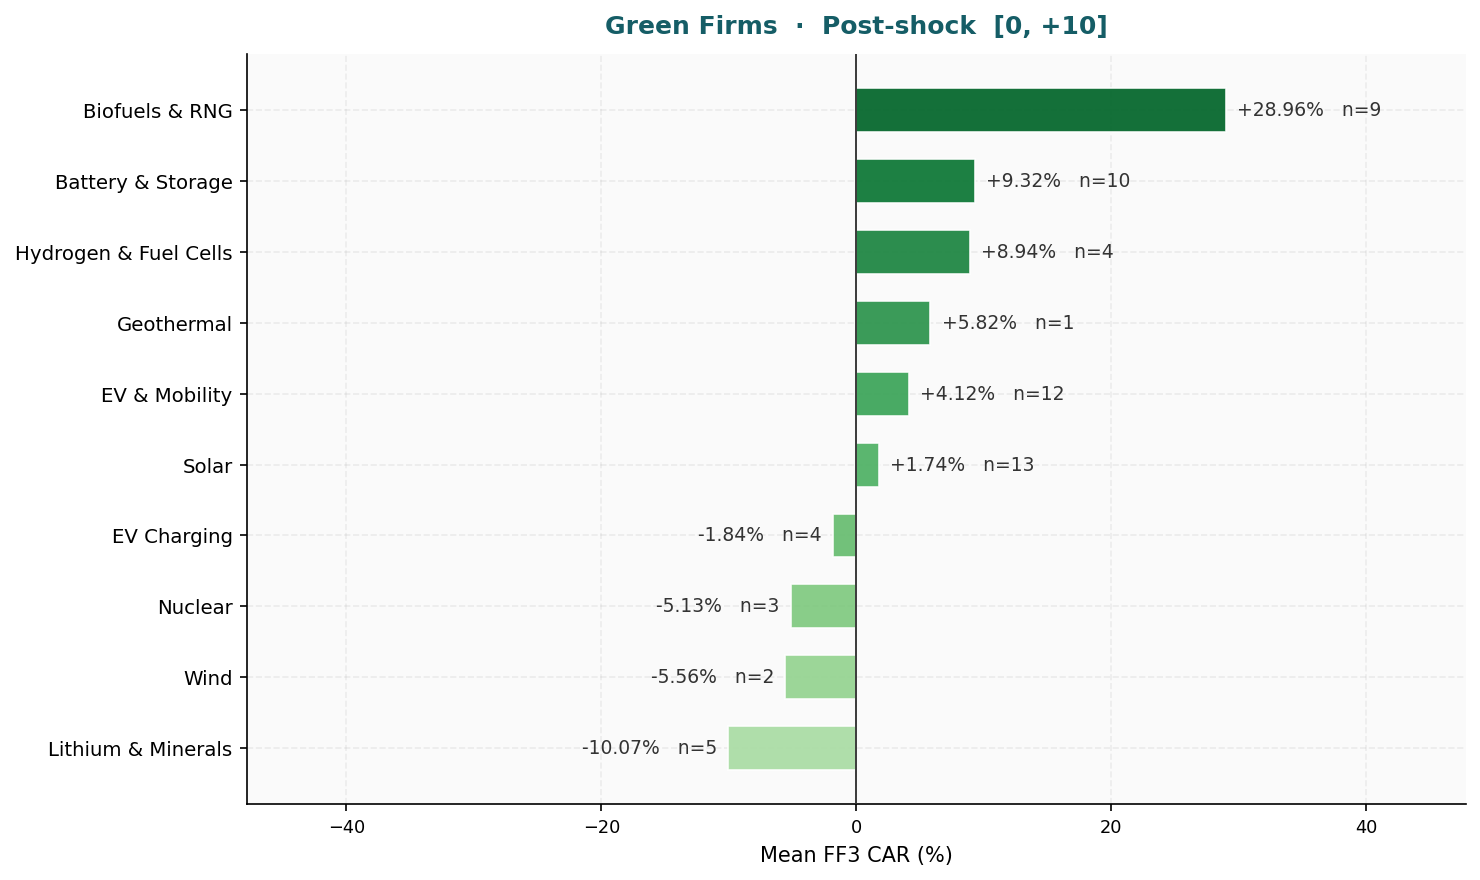

Saved → sector_CAR_green_p0_p10.png
  SKIP brown [-1,+1] — no data
  SKIP brown [+0,+10] — no data


In [80]:
# ── One figure per (group, window) combination ───────────────────────
windows     = ["[-1,+1]", "[+0,+10]"]
win_titles  = {"[-1,+1]": "Immediate  [−1, +1]", "[+0,+10]": "Post-shock  [0, +10]"}
group_labels = {"green": "Green Firms", "brown": "Brown Firms"}
group_cmaps  = {"green": cm.get_cmap("Greens"), "brown": cm.get_cmap("YlOrBr")}
group_colors = {"green": GREEN, "brown": BROWN}

for group in ["green", "brown"]:
    for window in windows:
        sub = (
            sector_summary[
                (sector_summary["energy_type"] == group) &
                (sector_summary["window"] == window)
            ]
            .sort_values("mean_CAR", ascending=True)
            .reset_index(drop=True)
        )

        if sub.empty:
            print(f"  SKIP {group} {window} — no data")
            continue

        n_bars = len(sub)
        cmap   = group_cmaps[group]
        colors = [cmap(0.35 + 0.55 * i / max(n_bars - 1, 1)) for i in range(n_bars)]

        # Dynamic figure height: scale with number of bars
        fig_h = max(4.5, 0.45 * n_bars + 1.5)
        fig, ax = plt.subplots(figsize=(10, fig_h))

        bars = ax.barh(
            sub["subsector"], sub["mean_CAR"],
            color=colors, edgecolor="white", linewidth=0.8,
            height=0.62, alpha=0.92, zorder=3
        )

        x_range = sub["mean_CAR"].abs().max() if len(sub) else 1
        offset  = x_range * 0.03

        for bar, (_, row) in zip(bars, sub.iterrows()):
            x  = bar.get_width()
            ha = "left" if x >= 0 else "right"
            ax.text(
                x + (offset if x >= 0 else -offset),
                bar.get_y() + bar.get_height() / 2,
                f"{x:+.2f}%   n={int(row['n'])}",
                va="center", ha=ha, fontsize=9, color="#333333"
            )

        ax.axvline(0, color="#333333", lw=0.9, zorder=4)
        ax.set_xlim(-(x_range * 1.65), x_range * 1.65)
        ax.set_xlabel("Mean FF3 CAR (%)", fontsize=10)
        ax.set_title(
            f"{group_labels[group]}  ·  {win_titles[window]}",
            color=group_colors[group], fontweight="semibold", fontsize=12, pad=10
        )
        ax.tick_params(axis="y", labelsize=9.5)
        ax.tick_params(axis="x", labelsize=8.5)
        ax.spines[["top","right"]].set_visible(False)
        ax.set_axisbelow(True)
        ax.grid(axis="x", alpha=0.18, linestyle="--")

        safe_win = window.replace("[","").replace("]","").replace("+","p").replace(",","_")
        fname = f"sector_CAR_{group}_{safe_win}.png"
        plt.tight_layout()
        plt.show()
        print(f"Saved → {fname}")

### Oil-Volatility Extension (H2)

**H2:** Oil-market volatility explains part of the green abnormal return.
A positive Δ = (baseline CAR − oil-augmented CAR) supports H2 for that volatility proxy.

In [81]:
oil_models = [m for m in car_results["model"].unique()
              if any(x in m for x in ["BRENTVOL","OVX","WTIVOL"])]
print("Oil-augmented results — Firms:")
display(car_results[
    (car_results["universe"]=="Firms") &
    (car_results["model"].isin(oil_models)) &
    (car_results["group"]=="green")
].round({"mean_CAR%":3,"SE%":3,"t_stat":3,"p_two":4,"p_one":4}))

Oil-augmented results — Firms:


,universe,model,window,group,weighting,n,n_eff,mean_CAR%,SE%,t_stat,p_two,p_one,sig_one,sig_two
522,Firms,CAPM+OVX,"[+0,+10]",green,EW,104,104.000000,2.804,2.945,0.952,0.3432,0.1716,,
523,Firms,CAPM+OVX,"[+0,+10]",green,VW,103,3.048795,-2.907,2.336,-1.244,0.3368,0.8316,,
526,Firms,CAPM+OVX,"[+0,+15]",green,EW,104,104.000000,1.407,4.025,0.350,0.7274,0.3637,,
527,Firms,CAPM+OVX,"[+0,+15]",green,VW,103,3.048795,-6.595,3.273,-2.015,0.1784,0.9108,,
530,Firms,CAPM+OVX,"[+0,+20]",green,EW,104,104.000000,2.537,5.151,0.493,0.6234,0.3117,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823,Firms,FF3+WTIVOL,"[-30,+30]",green,VW,103,3.048795,-33.970,17.227,-1.972,0.1843,0.9078,,
826,Firms,FF3+WTIVOL,"[-5,+5]",green,EW,104,104.000000,6.177,2.931,2.107,0.0375,0.0188,**,**
827,Firms,FF3+WTIVOL,"[-5,+5]",green,VW,103,3.048795,-12.409,6.455,-1.922,0.1915,0.9043,,
830,Firms,FF3+WTIVOL,"[-7,+7]",green,EW,104,104.000000,8.773,3.278,2.676,0.0087,0.0043,***,***


In [82]:
def h2_report(car_results, universe, group):
    def h1_verdict(car, p):
        if car > 0 and p < 0.05: return "✓ H1"
        if car > 0 and p < 0.10: return "~ H1"
        return "✗"

    def h2_verdict(delta, aug_p):
        if delta > 0 and aug_p < 0.10: return "✓ H2"
        if delta > 0:                   return "~ H2"
        return "✗"

    def sig(p):
        if pd.isna(p):  return "   "
        if p < 0.01:    return "***"
        if p < 0.05:    return "** "
        if p < 0.10:    return "*  "
        return "   "

    COL = 115
    print("\n" + "═"*COL)
    print(f"H2 REPORT — {universe.upper()}, {group.upper()} Group")
    print("H1: green CAR > 0 and significant  |  "
          "H2: augmented CAR < baseline CAR (OVX absorbs part of AR)")
    print("═"*COL)

    hdr = (f"  {'W':2}  {'Window':<12}  "
           f"{'Base CAR%':>9}  {'t':>6}  {'p':>6}  {'sig':3}  {'H1':5}  │  "
           f"{'Aug CAR%':>9}  {'t':>6}  {'p':>6}  {'sig':3}  {'H1':5}  │  "
           f"{'ΔCAR':>7}  {'H2':6}")

    for base_model in ["CAPM", "FF3"]:
        for oil_name in ["OVX", "BVOL", "WTIVOL"]:
            aug_model = f"{base_model}+{oil_name}"
            if car_results[car_results["model"] == aug_model].empty:
                continue

            print(f"\n── {base_model}  vs  {aug_model} ──")
            print(hdr)
            print("  " + "─"*(COL - 2))

            for window in WIN_LABELS:
                for weighting in ["EW", "VW"]:
                    def get(model):
                        r = car_results[
                            (car_results["universe"]  == universe) &
                            (car_results["model"]     == model) &
                            (car_results["window"]    == window) &
                            (car_results["group"]     == group) &
                            (car_results["weighting"] == weighting)
                        ]
                        if r.empty:
                            return None, None, None
                        row = r.iloc[0]
                        return row["mean_CAR%"], row["t_stat"], row["p_one"]

                    bc, bt, bp = get(base_model)
                    ac, at, ap = get(aug_model)
                    if bc is None or ac is None:
                        continue

                    delta = bc - ac
                    print(
                        f"  {weighting:2}  {window:<12}  "
                        f"{bc:>+9.2f}  {bt:>6.2f}  {bp:>6.3f}  {sig(bp)}  "
                        f"{h1_verdict(bc,bp):5}  │  "
                        f"{ac:>+9.2f}  {at:>6.2f}  {ap:>6.3f}  {sig(ap)}  "
                        f"{h1_verdict(ac,ap):5}  │  "
                        f"{delta:>+7.2f}  {h2_verdict(delta,ap):6}"
                    )
            print()

h2_report(car_results, "Firms", group="green")
h2_report(car_results, "Firms", group="brown")
h2_report(car_results, "ETFs",  group="green")
h2_report(car_results, "ETFs",  group="brown")


═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
H2 REPORT — FIRMS, GREEN Group
H1: green CAR > 0 and significant  |  H2: augmented CAR < baseline CAR (OVX absorbs part of AR)
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════

── CAPM  vs  CAPM+OVX ──
  W   Window        Base CAR%       t       p  sig  H1     │   Aug CAR%       t       p  sig  H1     │     ΔCAR  H2    
  ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  EW  [-1,+1]           -2.84   -4.84   1.000       ✗      │      -3.71   -5.21   1.000       ✗      │    +0.87  ~ H2  
  VW  [-1,+1]           -0.96   -2.51   0.937       ✗      │      -2.71   -4.19   0.975       ✗      │    +1.75  ~ H2  
  EW  [-3,+3]           -3.16   -2.63   0.995       ✗      │      -4.85   -2.81   0.997       ✗      │    +1.69  ~ H2  
  VW  [-3,+3]     

In [87]:
POST_WIN = (0, 60)

green_ev = firm_ev[
    (firm_ev["energy_type"] == "green") &
    (firm_ev["t"].between(*POST_WIN)) &
    firm_ev["AR_ff3"].notna() &
    firm_ev["brent_parkinson_vol"].notna()
].copy()

gamma_rows = []
for ric, grp in green_ev.groupby("ric"):
    if len(grp) < 5:
        continue
    y = grp["AR_ff3"].values
    X = np.c_[np.ones(len(grp)), grp["brent_parkinson_vol"].values]
    try:
        b, _, _, _ = lstsq(X, y, rcond=None)
        resid = y - X @ b
        sigma2  = (resid ** 2).sum() / (len(y) - 2)
        XtX_inv = np.linalg.inv(X.T @ X)
        se_b    = np.sqrt(np.diag(sigma2 * XtX_inv))
        gamma   = b[1]
        se_g    = se_b[1]
        t_g     = gamma / (se_g + 1e-30)
    except Exception:
        continue
    gamma_rows.append({"ric": ric, "gamma": gamma, "se": se_g, "t_stat": t_g})

gamma_df  = pd.DataFrame(gamma_rows)
n_firms   = len(gamma_df)
gamma_bar = gamma_df["gamma"].mean()
se_bar    = gamma_df["gamma"].std(ddof=1) / np.sqrt(n_firms)
t_bar     = gamma_bar / (se_bar + 1e-30)
p_two_bar = 2 * stats.t.sf(abs(t_bar), df=n_firms - 1)
p_neg_bar = stats.t.cdf(t_bar, df=n_firms - 1)

rng        = np.random.default_rng(42)
gammas_arr = gamma_df["gamma"].values
gammas_c   = gammas_arr - gamma_bar
boot_means = np.array([
    rng.choice(gammas_c, size=n_firms, replace=True).mean()
    for _ in range(5_000)
])
p_boot_neg = (boot_means <= gamma_bar).mean()

print("\n" + "═"*70)
print("A. FACTOR OMISSION TEST — BrentVol in FF3 residuals")
print(f"   Green firms with sufficient post-event obs: {n_firms}")
print(f"   Post-event window: t ∈ [{POST_WIN[0]}, {POST_WIN[1]}]")
print("─"*70)
print(f"   Cross-sectional mean γ̄  = {gamma_bar:.6f}")
print(f"   SE(γ̄)                   = {se_bar:.6f}")
print(f"   t-stat                  = {t_bar:.3f}")
print(f"   p-value (two-sided)     = {p_two_bar:.4f}")
print(f"   p-value (one-sided <0)  = {p_neg_bar:.4f}")
print(f"   Bootstrap p (γ̄ ≤ obs)   = {p_boot_neg:.4f}")
print("═"*70)


══════════════════════════════════════════════════════════════════════
A. FACTOR OMISSION TEST — BrentVol in FF3 residuals
   Green firms with sufficient post-event obs: 104
   Post-event window: t ∈ [0, 60]
──────────────────────────────────────────────────────────────────────
   Cross-sectional mean γ̄  = 0.019068
   SE(γ̄)                   = 0.072832
   t-stat                  = 0.262
   p-value (two-sided)     = 0.7940
   p-value (one-sided <0)  = 0.6030
   Bootstrap p (γ̄ ≤ obs)   = 0.6014
══════════════════════════════════════════════════════════════════════


In [88]:
base_cars = asset_cars[
    (asset_cars["universe"] == "Firms") &
    (asset_cars["model"] == "FF3") &
    (asset_cars["group"] == "green")
][["ric","window","CAR"]].rename(columns={"CAR":"CAR_ff3"})

aug_cars = asset_cars[
    (asset_cars["universe"] == "Firms") &
    (asset_cars["model"] == "FF3+BVOL") &
    (asset_cars["group"] == "green")
][["ric","window","CAR"]].rename(columns={"CAR":"CAR_aug"})

delta_df = base_cars.merge(aug_cars, on=["ric","window"], how="inner")
delta_df["delta_CAR"] = delta_df["CAR_aug"] - delta_df["CAR_ff3"]

delta_rows = []
for window, grp in delta_df.groupby("window"):
    d = grp["delta_CAR"].dropna().values
    n = len(d)
    if n < 2:
        continue
    mean_d  = d.mean()
    se_d    = d.std(ddof=1) / np.sqrt(n)
    t_d     = mean_d / (se_d + 1e-30)
    p_one_d = stats.t.sf(t_d, df=n - 1)
    d0     = d - mean_d
    boot_d = np.array([
        rng.choice(d0, size=n, replace=True).mean()
        for _ in range(5_000)
    ])
    p_boot_d = (boot_d >= mean_d).mean()
    delta_rows.append({
        "window": window, "n": n,
        "mean_ΔCAR%": mean_d * 100, "SE%": se_d * 100,
        "t_stat": t_d, "p_one": p_one_d,
        "p_boot": p_boot_d, "sig": stars(p_one_d),
    })

delta_table = pd.DataFrame(delta_rows)
win_order = {w: i for i, w in enumerate(WIN_LABELS)}
delta_table["_order"] = delta_table["window"].map(win_order)
delta_table = (delta_table.sort_values("_order")
               .drop(columns="_order").reset_index(drop=True))

print("\n" + "═"*80)
print("B. ΔCAR BIAS CORRECTION TEST — Green Firms")
print("   ΔCAR = CAR(FF3+BrentVol) − CAR(FF3)  |  H₁: ΔCAR > 0")
print("═"*80)
print(delta_table[["window","n","mean_ΔCAR%","SE%","t_stat","p_one","p_boot","sig"]]
      .to_string(index=False, float_format="{:.3f}".format))
print("═"*80)



════════════════════════════════════════════════════════════════════════════════
B. ΔCAR BIAS CORRECTION TEST — Green Firms
   ΔCAR = CAR(FF3+BrentVol) − CAR(FF3)  |  H₁: ΔCAR > 0
════════════════════════════════════════════════════════════════════════════════
   window   n  mean_ΔCAR%   SE%  t_stat  p_one  p_boot sig
  [-1,+1] 104       0.468 0.170   2.753  0.003   0.004 ***
  [-3,+3] 104       0.640 0.250   2.557  0.006   0.008 ***
  [-5,+5] 104       6.530 1.922   3.397  0.000   0.001 ***
  [-7,+7] 104       7.718 2.322   3.324  0.001   0.001 ***
  [+0,+7] 104       8.035 2.267   3.544  0.000   0.001 ***
 [+0,+10] 104       8.397 2.383   3.523  0.000   0.001 ***
 [+0,+15] 104      11.346 2.960   3.833  0.000   0.000 ***
 [+0,+20] 104      11.628 3.217   3.615  0.000   0.001 ***
 [+0,+25] 104      12.473 3.438   3.628  0.000   0.000 ***
[-25,+25] 104      11.568 3.483   3.322  0.001   0.001 ***
[-30,+30] 104      12.641 3.752   3.369  0.001   0.001 ***
[-10,+50] 104      15.025 4.50

## Placebo Test

To verify that the observed green-firm CAR is not an artifact of the estimation
procedure or a chance feature of the return distribution, 100 evenly-spaced fake
event dates are drawn from the pre-event period (all strictly before $t = -31$,
well outside the true event window).

The same model parameters estimated on the true estimation window are applied to
each placebo window — only the window alignment changes. Two models are tested
in parallel: **CAPM** and **FF3**.

Four separate figures are produced:

| Figure | Universe | 
|--------|----------|
| Green Firms | Firms with `energy_type == "green"` |
| Brown Firms | Firms with `energy_type == "brown"` |
| Green ETFs  | ETFs with `asset_group == "green"` |
| Brown ETFs  | ETFs with `asset_group == "brown"` |

Each figure shows two panels (CAPM · FF3) containing:
- **Grey paths** — individual VW CAR for each of the 100 fake dates
- **Shaded band** — 5th–95th percentile placebo envelope  
- **Colored line** — true event VW CAR path

A true-event path outside the 90% envelope indicates the observed result is
unlikely to arise under the null of no event effect.

In [89]:
# ═══════════════════════════════════════════════════════════════════════════════
# PLACEBO TEST — CAPM · FF3
# ═══════════════════════════════════════════════════════════════════════════════

N_PLACEBO = 100

# ── Candidate fake event dates ───────────────────────────────────────────────
candidate_t0 = (
    firm_panel[["date", "t"]].drop_duplicates()
    .sort_values("t")
    .query(f"t <= -31 and t >= {firm_panel['t'].min() - PLOT_START}")
    .copy()
)
idx           = np.linspace(0, len(candidate_t0) - 1, N_PLACEBO).round().astype(int)
placebo_dates = (candidate_t0.iloc[idx]
                 .drop_duplicates("t")
                 .reset_index(drop=True))
print(f"Placebo dates selected: {len(placebo_dates)}")
print(f"  t range: {placebo_dates['t'].min()} … {placebo_dates['t'].max()}")


# ────────────────────────────────────────────────────────────────────────────
# 1.  Pre-compute CAPM and FF3 ARs for full pre-event panels
# ────────────────────────────────────────────────────────────────────────────
MODEL_PANEL_PLAC = [
    ("CAPM", "AR_capm_plac"),
    ("FF3",  "AR_ff3_plac"),
]

# --- Firms ---
valid_firms     = set(firm_params["FF3"].keys())
firm_plac_panel = (firm_panel[firm_panel["ric"].isin(valid_firms)]
                   .copy()
                   .merge(firm_weights, on="ric", how="left"))

for model_key, fmap, ar_col in [
    ("CAPM", {"Mkt_RF": "Mkt"},                             "AR_capm_plac"),
    ("FF3",  {"Mkt_RF": "Mkt", "SMB": "SMB", "HML": "HML"}, "AR_ff3_plac"),
]:
    firm_plac_panel[ar_col] = [
        (row["excess_ret"]
         - expected_return(row, firm_params[model_key][row["ric"]], fmap))
        if row["ric"] in firm_params.get(model_key, {}) else np.nan
        for _, row in firm_plac_panel.iterrows()
    ]

# --- ETFs ---
valid_etfs     = set(etf_params["FF3"].keys())
etf_plac_panel = (etf_panel[etf_panel["ric"].isin(valid_etfs)]
                  .copy()
                  .merge(etf_weights, on="ric", how="left"))

for model_key, fmap, ar_col in [
    ("CAPM", {"Mkt_RF": "Mkt"},                              "AR_capm_plac"),
    ("FF3",  {"Mkt_RF": "Mkt", "SMB": "SMB", "HML": "HML"}, "AR_ff3_plac"),
]:
    etf_plac_panel[ar_col] = [
        (row["excess_ret"]
         - expected_return(row, etf_params[model_key][row["ric"]], fmap))
        if row["ric"] in etf_params.get(model_key, {}) else np.nan
        for _, row in etf_plac_panel.iterrows()
    ]

print("AR pre-computation complete.")
print(f"  firm_plac_panel AR cols: "
      f"{[c for c in firm_plac_panel.columns if 'plac' in c]}")
print(f"  etf_plac_panel  AR cols: "
      f"{[c for c in etf_plac_panel.columns  if 'plac' in c]}")


# ────────────────────────────────────────────────────────────────────────────
# 2.  Build VW CAR paths for placebo and true event
# ────────────────────────────────────────────────────────────────────────────

def vw_car_at_tau(sub_panel, group_col, group, ar_col, tau, pre_col="pre_event_mcap"):
    day = (sub_panel[(sub_panel[group_col] == group) & (sub_panel["tau"] == tau)]
           .dropna(subset=[ar_col, pre_col])
           .query(f"{pre_col} > 0"))
    if len(day) == 0:
        return 0.0
    w = day[pre_col] / day[pre_col].sum()
    return (w * day[ar_col]).sum()


def build_placebo_paths(plac_panel, group_col, plac_dates):
    rows = []
    for _, pdate in plac_dates.iterrows():
        fake_t0 = pdate["t"]
        tmp = plac_panel.copy()
        tmp["tau"] = tmp["t"] - fake_t0
        tmp = tmp[tmp["tau"].between(PLOT_START, PLOT_END)]

        for model, ar_col in MODEL_PANEL_PLAC:
            if ar_col not in tmp.columns:
                continue
            for group in ["green", "brown"]:
                ar_series = []
                for tau in range(PLOT_START, PLOT_END + 1):
                    ar_series.append(vw_car_at_tau(tmp, group_col, group, ar_col, tau))
                car_series = np.cumsum(ar_series)
                for tau, car in zip(range(PLOT_START, PLOT_END + 1), car_series):
                    rows.append({"fake_t0": fake_t0, "model": model,
                                 "group": group, "tau": tau, "CAR_VW": car})

    return (pd.DataFrame(rows)
            .sort_values(["fake_t0", "model", "group", "tau"])
            .reset_index(drop=True))


def build_true_paths(ev_panel, group_col, weights, model_ar_map):
    ev_w = ev_panel.merge(weights, on="ric", how="left")
    rows = []
    for model, ar_col in model_ar_map.items():
        if ar_col not in ev_w.columns:
            continue
        for group in ["green", "brown"]:
            ar_series = []
            for tau in range(PLOT_START, PLOT_END + 1):
                day = (ev_w[(ev_w[group_col] == group) & (ev_w["t"] == tau)]
                       .dropna(subset=[ar_col, "pre_event_mcap"])
                       .query("pre_event_mcap > 0"))
                if len(day) == 0:
                    ar_series.append(0.0)
                else:
                    w = day["pre_event_mcap"] / day["pre_event_mcap"].sum()
                    ar_series.append((w * day[ar_col]).sum())
            for tau, car in zip(range(PLOT_START, PLOT_END + 1),
                                np.cumsum(ar_series)):
                rows.append({"model": model, "group": group,
                             "tau": tau, "CAR_VW": car})
    return pd.DataFrame(rows)


print("Building placebo paths …")
firm_plac_paths = build_placebo_paths(firm_plac_panel, "energy_type", placebo_dates)
etf_plac_paths  = build_placebo_paths(etf_plac_panel,  "asset_group",  placebo_dates)

firm_true_paths = build_true_paths(
    firm_ev, "energy_type", firm_weights,
    {"CAPM": "AR_capm", "FF3": "AR_ff3"}
)
etf_true_paths = build_true_paths(
    etf_ev, "asset_group", etf_weights,
    {"CAPM": "AR_capm", "FF3": "AR_ff3"}
)

print(f"  Firm placebo paths: {len(firm_plac_paths):,} rows")
print(f"  ETF  placebo paths: {len(etf_plac_paths):,}  rows")

Placebo dates selected: 100
  t range: -1258 … -31
AR pre-computation complete.
  firm_plac_panel AR cols: ['AR_capm_plac', 'AR_ff3_plac']
  etf_plac_panel  AR cols: ['AR_capm_plac', 'AR_ff3_plac']
Building placebo paths …
  Firm placebo paths: 32,400 rows
  ETF  placebo paths: 32,400  rows


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3579, in run_code
  File "/var/folders/6n/p578p__s54j_ngsncpgm562m0000gn/T/ipykernel_18820/3309324293.py", line 71, in <module>
    plt.savefig(FIG_DIR / fname, dpi=200, bbox_inches="tight")
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/matplotlib/pyplot.py", line 1250, in savefig
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/matplotlib/figure.py", line 3490, in savefig
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/matplotlib/backend_bases.py", line 2186, in print_figure
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/matplotlib/backend_bases.py", line 2042, in <lambda>
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv

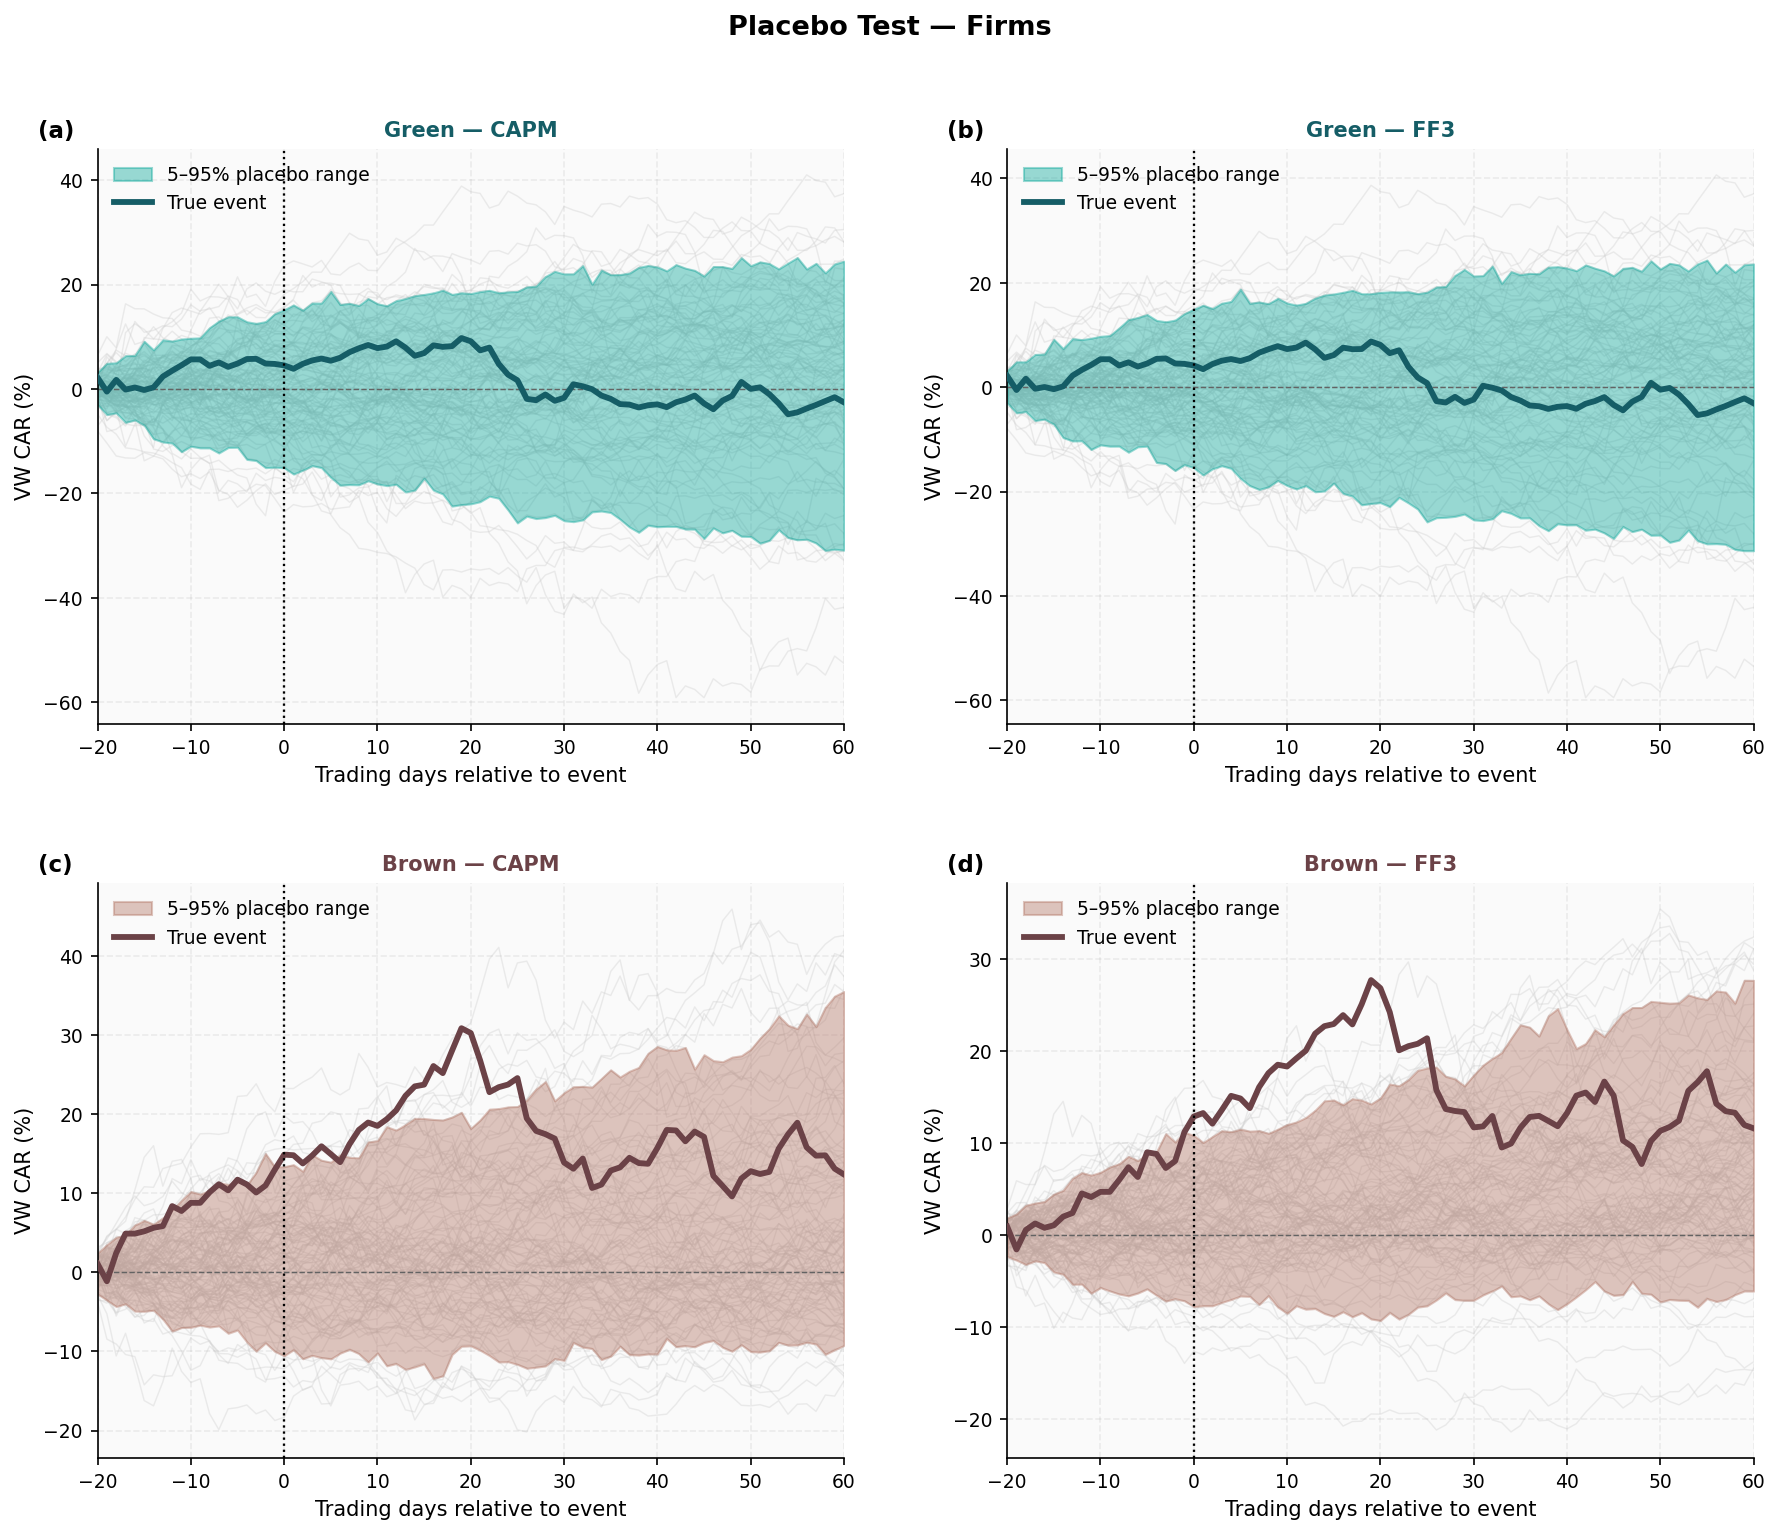

In [90]:
# ═══════════════════════════════════════════════════════════════════════════════
# PLACEBO FIGURES — 2 figures (Firms | ETFs), each with 2×2 subplots
# rows = Green / Brown   |   cols = CAPM / FF3
# ═══════════════════════════════════════════════════════════════════════════════

UNIV_CONFIGS = [
    ("Firms", firm_plac_paths, firm_true_paths, "placebo_firms.png"),
    ("ETFs",  etf_plac_paths,  etf_true_paths,  "placebo_etfs.png"),
]

for univ_label, plac_paths, true_paths, fname in UNIV_CONFIGS:

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=False)
    fig.suptitle(f"Placebo Test — {univ_label}", fontsize=13, fontweight="bold", y=1.02)

    for row_idx, group in enumerate(["green", "brown"]):
        color  = GREEN   if group == "green" else BROWN
        band_c = GREEN_L if group == "green" else BROWN_L

        for col_idx, model in enumerate(["CAPM", "FF3"]):
            ax = axes[row_idx, col_idx]

            # ── Panel label ───────────────────────────────────────────
            panel = chr(ord("a") + row_idx * 2 + col_idx)
            ax.text(-0.08, 1.05, f"({panel})",
                    transform=ax.transAxes, fontsize=11,
                    fontweight="bold", va="top")

            sub_p = plac_paths[(plac_paths["model"] == model) &
                               (plac_paths["group"] == group)]
            sub_t = true_paths[(true_paths["model"] == model) &
                               (true_paths["group"] == group)]

            if sub_p.empty:
                ax.set_visible(False)
                continue

            # ── Individual placebo paths ──────────────────────────────
            for _, g in sub_p.groupby("fake_t0"):
                ax.plot(g["tau"], g["CAR_VW"] * 100,
                        color="#cccccc", lw=0.7, alpha=0.35, zorder=1)

            # ── 5–95% envelope ────────────────────────────────────────
            q = (sub_p.groupby("tau")["CAR_VW"]
                 .quantile([0.05, 0.95])
                 .unstack()
                 .reset_index()
                 .rename(columns={0.05: "q05", 0.95: "q95"}))
            ax.fill_between(q["tau"], q["q05"] * 100, q["q95"] * 100,
                            color=band_c, alpha=0.40,
                            label="5–95% placebo range", zorder=2)

            # ── True event path ───────────────────────────────────────
            if not sub_t.empty:
                ax.plot(sub_t["tau"], sub_t["CAR_VW"] * 100,
                        color=color, lw=2.8, label="True event", zorder=4)
                final = sub_t["CAR_VW"].iloc[-1] * 100

            ax.axvline(0, color="black", lw=1.1, ls=":", zorder=4)
            ax.axhline(0, color=GREY,    lw=0.7, ls="--")
            ax.set_xlim(PLOT_START, PLOT_END)
            ax.set_xlabel("Trading days relative to event", fontsize=10)
            ax.set_ylabel("VW CAR (%)", fontsize=10)
            ax.set_title(f"{group.capitalize()} — {model}",
                         color=color, fontweight="semibold", fontsize=10)
            ax.legend(frameon=False, fontsize=9, loc="upper left")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    plt.tight_layout(w_pad=3.0, h_pad=3.0)
    plt.savefig(FIG_DIR / fname, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")

### Daily Abnormal Return: Bar Chart + Cumulative AR Line

For each model, the value-weighted (VW) daily abnormal return is shown as a bar chart.
Bar opacity reflects statistical significance: opaque bars are significantly different
from zero at the 10% level or better (cross-sectional t-test); faded bars are
insignificant. Stars denote significance level.

The orange line overlaid on each panel is the cumulative abnormal return (CAR),
re-based to zero at $t = 0$ so the post-event accumulation reads directly from
the chart. The left axis measures the daily VW AR (%); the right axis measures
the cumulative AR (%).

One figure per (group × universe) combination; panels within each figure correspond
to models: **CAPM**, **FF3**, **CAPM+OVX**, **FF3+OVX**.

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3579, in run_code
  File "/var/folders/6n/p578p__s54j_ngsncpgm562m0000gn/T/ipykernel_18820/1957580967.py", line 96, in <module>
    plot_daily_ar_bars(
  File "/var/folders/6n/p578p__s54j_ngsncpgm562m0000gn/T/ipykernel_18820/1957580967.py", line 81, in plot_daily_ar_bars
    plt.savefig(FIG_DIR / fig_fname, dpi=200, bbox_inches="tight")
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/matplotlib/pyplot.py", line 1250, in savefig
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/matplotlib/figure.py", line 3490, in savefig
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/matplotlib/backend_bases.py", line 2186, in print_figure
  File "/Users/shirindehghannezhad/Documents/Thesis Project/ven

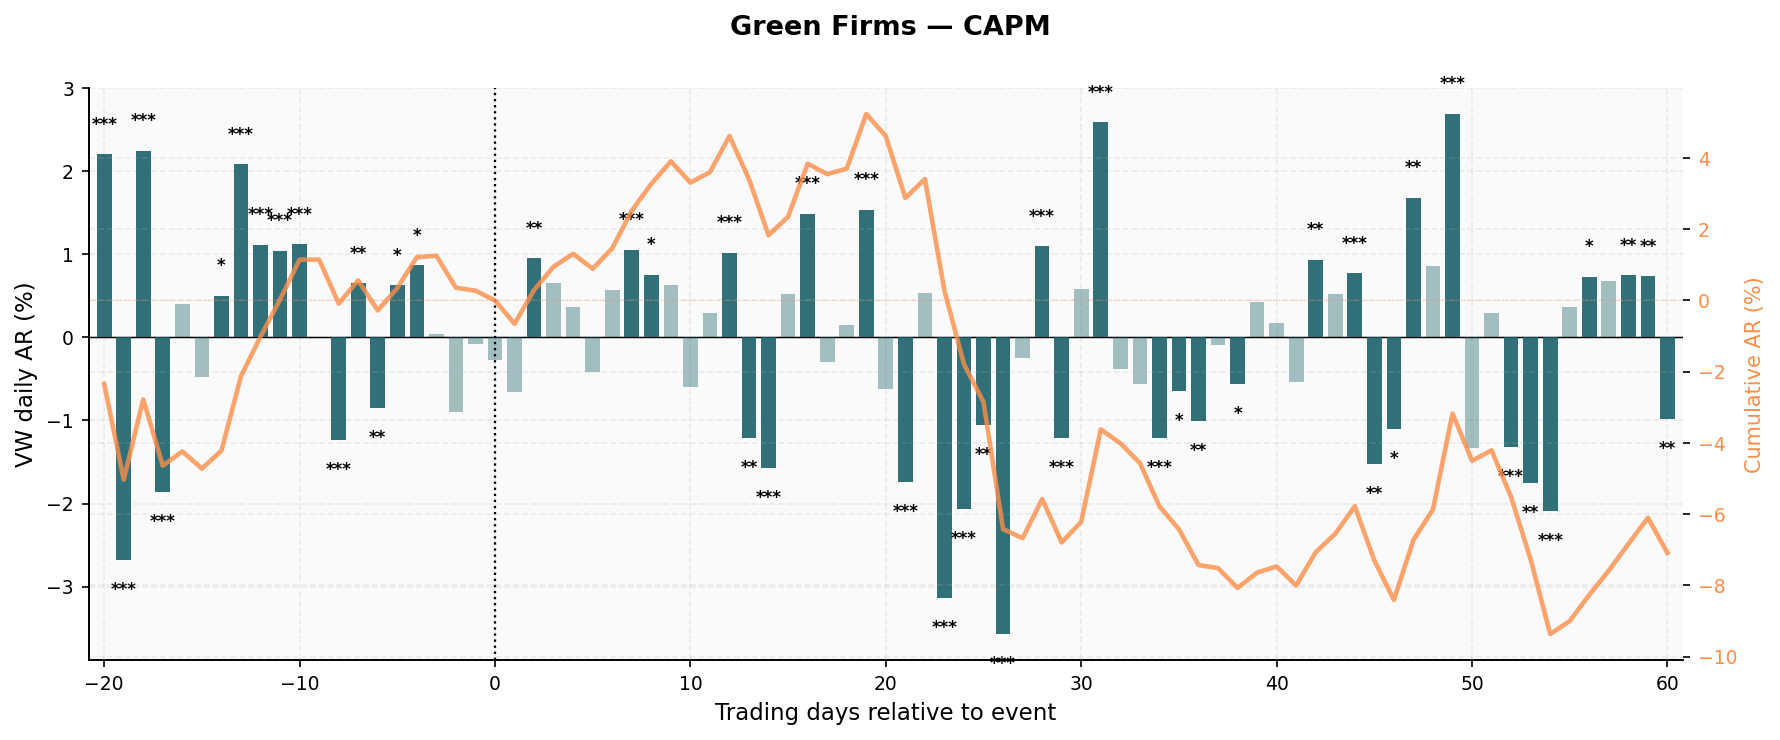

In [91]:
# ═══════════════════════════════════════════════════════════════════════════════
# DAILY VW AR BAR CHART + CUMULATIVE AR LINE — one figure per model
# ═══════════════════════════════════════════════════════════════════════════════

def plot_daily_ar_bars(ev_base, group_col, group, weights,
                       ar_model_list, suptitle, fname, color):
    for ar_col, model_label in ar_model_list:

        if ar_col not in ev_base.columns:
            print(f"  SKIP {model_label} — column {ar_col} not found"); continue

        ev = (ev_base[(ev_base[group_col] == group) &
                      ev_base["t"].between(PLOT_START, PLOT_END)]
              .copy()
              .merge(weights, on="ric", how="left"))

        t_vals, ar_vals, star_vals = [], [], []
        for t in range(PLOT_START, PLOT_END + 1):
            day = (ev[ev["t"] == t]
                   .dropna(subset=[ar_col, "pre_event_mcap"])
                   .query("pre_event_mcap > 0")
                   .copy())
            if len(day) > 1:
                day["w"] = day["pre_event_mcap"] / day["pre_event_mcap"].sum()
                ar_vw    = (day["w"] * day[ar_col]).sum()
                se_cs    = day[ar_col].std(ddof=1) / np.sqrt(len(day))
                t_stat   = ar_vw / (se_cs + 1e-12)
                p_val    = 2 * stats.t.sf(abs(t_stat), df=len(day) - 1)
            elif len(day) == 1:
                ar_vw, p_val = day[ar_col].iloc[0], 1.0
            else:
                ar_vw, p_val = 0.0, 1.0
            t_vals.append(t)
            ar_vals.append(ar_vw * 100)
            star_vals.append(stars(p_val))

        fig, ax = plt.subplots(figsize=(12, 5))
        fig.suptitle(
            f"{suptitle.split('|')[0].strip()} — {model_label}",
            fontsize=13, fontweight="bold",
        )

        bar_alpha = [0.88 if s else 0.38 for s in star_vals]
        bars = ax.bar(t_vals, ar_vals, width=0.75, color=color, zorder=3)
        for b, a in zip(bars, bar_alpha):
            b.set_alpha(a)

        yr = max(abs(v) for v in ar_vals) if ar_vals else 1
        for t, v, s in zip(t_vals, ar_vals, star_vals):
            if s:
                y_pos = v + yr * 0.07 if v >= 0 else v - yr * 0.07
                ax.text(t, y_pos, s, ha="center",
                        va="bottom" if v >= 0 else "top",
                        fontsize=8, fontweight="bold")

        cum_raw = np.cumsum(ar_vals)
        t0_pos  = t_vals.index(0) if 0 in t_vals else 0
        cum     = [v - cum_raw[t0_pos] for v in cum_raw]

        ax2 = ax.twinx()
        ax2.plot(t_vals, cum, color="#fd8d49", lw=2.2, alpha=0.80,
                 label="Cumulative AR")
        ax2.axhline(0, color="#fd8d49", lw=0.5, ls=":", alpha=0.6)
        ax2.set_ylabel("Cumulative AR (%)", color="#fd8d49", fontsize=10)
        ax2.tick_params(axis="y", labelcolor="#fd8d49")
        ax2.spines["right"].set_edgecolor("#fd8d49")
        ax2.spines["top"].set_visible(False)

        ax.axhline(0, color="black", lw=0.7)
        ax.axvline(0, color="black", lw=1.1, ls=":", zorder=4)
        ax.set_xlim(PLOT_START - 0.8, PLOT_END + 0.8)
        ax.set_xlabel("Trading days relative to event", fontsize=11)
        ax.set_ylabel("VW daily AR (%)", fontsize=11)
        ax.spines["top"].set_visible(False)


        safe_model = model_label.replace("+", "_").replace(" ", "_")
        fig_fname  = fname.replace(".png", f"_{safe_model}.png")

        plt.tight_layout()
        plt.savefig(FIG_DIR / fig_fname, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved → {fig_fname}")


UNIVERSE_CONFIGS = [
    ("Firms", firm_ev, "energy_type", firm_weights),
    ("ETFs",  etf_ev,  "asset_group",  etf_weights),
]

for univ_label, ev_base, group_col, weights in UNIVERSE_CONFIGS:
    for group in ["green", "brown"]:
        color       = GREEN if group == "green" else BROWN
        group_label = group.capitalize()

        plot_daily_ar_bars(
            ev_base=ev_base,
            group_col=group_col, group=group, weights=weights,
            ar_model_list=[
                ("AR_capm", "CAPM"),
                ("AR_ff3",  "FF3"),
            ],
            suptitle=f"{group_label} {univ_label} | CAPM · FF3",
            fname=f"daily_AR_bar_{univ_label}_{group_label}.png",
            color=color,
        )

        plot_daily_ar_bars(
            ev_base=ev_base,
            group_col=group_col, group=group, weights=weights,
            ar_model_list=[
                ("AR_capm_ovx", "CAPM+OVX"),
                ("AR_ff3_ovx",  "FF3+OVX"),
            ],
            suptitle=f"{group_label} {univ_label} | OVX augmented",
            fname=f"daily_AR_bar_{univ_label}_{group_label}_OVX.png",
            color=color,
        )

        plot_daily_ar_bars(
            ev_base=ev_base,
            group_col=group_col, group=group, weights=weights,
            ar_model_list=[
                ("AR_capm_bvol", "CAPM+BrentVol"),
                ("AR_ff3_bvol",  "FF3+BrentVol"),
            ],
            suptitle=f"{group_label} {univ_label} | BrentVol augmented",
            fname=f"daily_AR_bar_{univ_label}_{group_label}_BrentVol.png",
            color=color,
        )

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3579, in run_code
  File "/var/folders/6n/p578p__s54j_ngsncpgm562m0000gn/T/ipykernel_18820/3866475776.py", line 137, in <module>
    plt.savefig(FIG_DIR / fname, dpi=200, bbox_inches="tight")
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/matplotlib/pyplot.py", line 1250, in savefig
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/matplotlib/figure.py", line 3490, in savefig
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/matplotlib/backend_bases.py", line 2186, in print_figure
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/matplotlib/backend_bases.py", line 2042, in <lambda>
  File "/Users/shirindehghannezhad/Documents/Thesis Project/ven

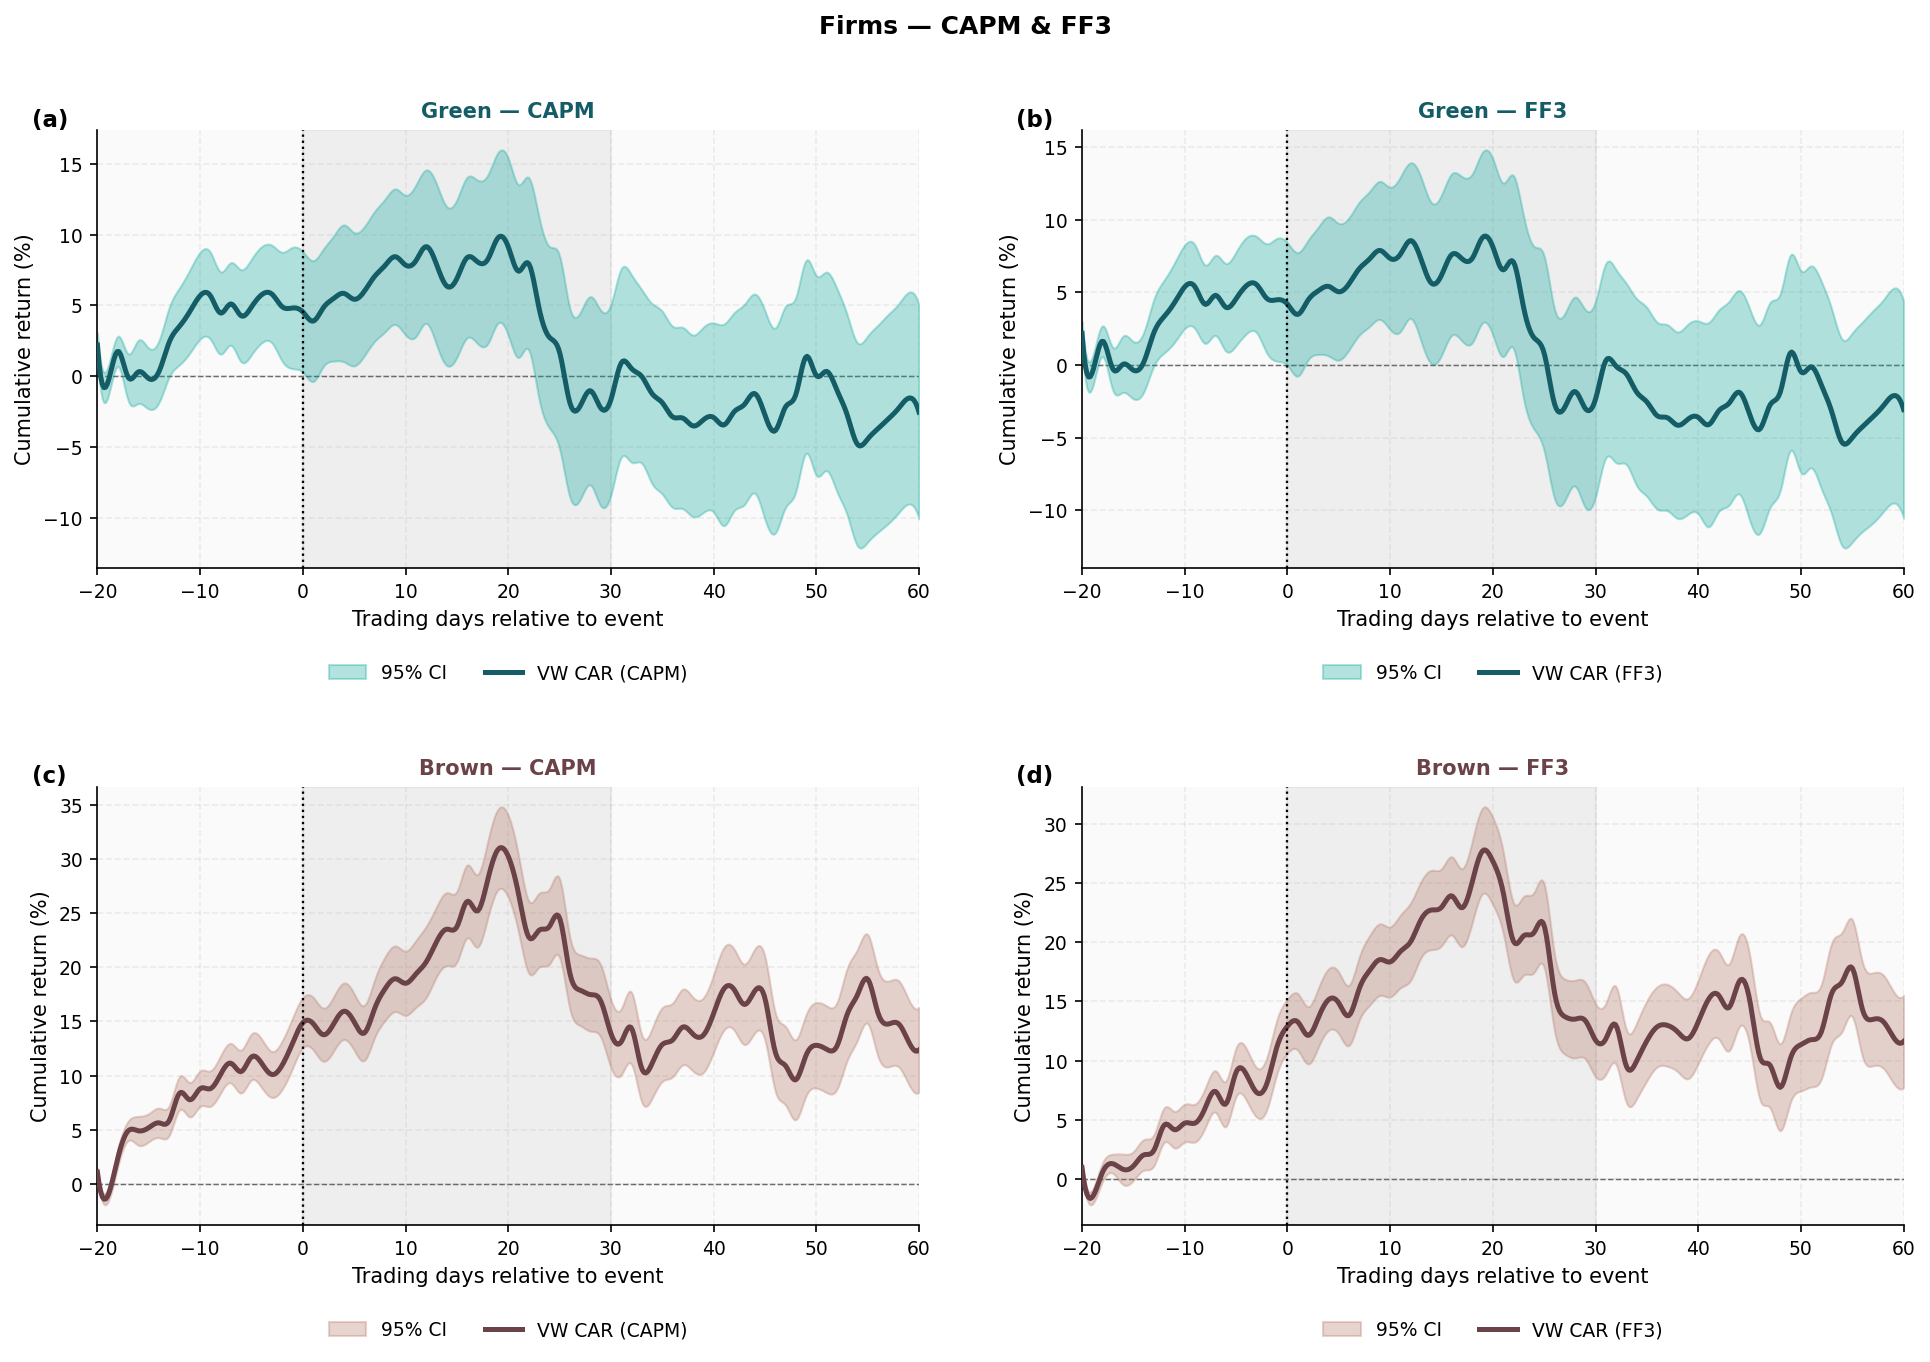

In [92]:
# ═══════════════════════════════════════════════════════════════════════════════
# CAR PATH FIGURES — VW
# 4 figures: Firms base | ETFs base | Firms augmented | ETFs augmented
# Each figure: 2×2 subplots (rows = Green/Brown, cols = model pair)
# ═══════════════════════════════════════════════════════════════════════════════
from scipy.interpolate import make_interp_spline

def model_car_path_data(ev_src, group_col, group, ar_col, weights, t_range):
    if ev_src is None or ar_col not in ev_src.columns:
        return None

    ev_g = (ev_src[(ev_src[group_col] == group) &
                   ev_src["t"].between(*t_range)]
            .copy()
            .merge(weights, on="ric", how="left"))

    t_vals, ar_vals, er_vals, ci_vals = [], [], [], []

    for t in range(t_range[0], t_range[1] + 1):
        day = (ev_g[ev_g["t"] == t]
               .dropna(subset=[ar_col, "excess_ret", "pre_event_mcap"])
               .query("pre_event_mcap > 0")
               .copy())

        if len(day) > 0:
            day["w"] = day["pre_event_mcap"] / day["pre_event_mcap"].sum()
            ar_vw    = (day["w"] * day[ar_col]).sum()
            er_vw    = (day["w"] * (day["excess_ret"] - day[ar_col])).sum()
        else:
            ar_vw = er_vw = 0.0

        t_vals.append(t)
        ar_vals.append(ar_vw)
        er_vals.append(er_vw)

        asset_cars = (
            ev_g[ev_g["t"].between(t_range[0], t) & ev_g[ar_col].notna()]
            .groupby("ric")[ar_col].sum()
        )
        if len(asset_cars) > 1:
            se = asset_cars.std(ddof=1) / np.sqrt(len(asset_cars))
            ci_vals.append(1.96 * se)
        else:
            ci_vals.append(0.0)

    cum_ar = np.cumsum(ar_vals)
    cum_er = np.cumsum(er_vals)
    ci_arr = np.array(ci_vals)

    return pd.DataFrame({
        "t":        t_vals,
        "CAR_VW":   cum_ar,
        "CI_lo":    cum_ar - ci_arr,
        "CI_hi":    cum_ar + ci_arr,
        "CumER_VW": cum_er,
    })


FIGURE_CONFIGS = [
    ("Firms — CAPM & FF3",
     "Firms", firm_ev, "energy_type", firm_weights,
     [("CAPM", "AR_capm"), ("FF3", "AR_ff3")],
     "car_Firms_base.png"),

    ("ETFs — CAPM & FF3",
     "ETFs", etf_ev, "asset_group", etf_weights,
     [("CAPM", "AR_capm"), ("FF3", "AR_ff3")],
     "car_ETFs_base.png"),

    ("Firms — CAPM+OVX & FF3+OVX",
     "Firms", firm_ev, "energy_type", firm_weights,
     [("CAPM+OVX", "AR_capm_ovx"), ("FF3+OVX", "AR_ff3_ovx")],
     "car_Firms_augmented.png"),

    ("ETFs — CAPM+OVX & FF3+OVX",
     "ETFs", etf_ev, "asset_group", etf_weights,
     [("CAPM+OVX", "AR_capm_ovx"), ("FF3+OVX", "AR_ff3_ovx")],
     "car_ETFs_augmented.png"),
]

for suptitle, univ_label, ev_base, group_col, weights, model_pair, fname in FIGURE_CONFIGS:

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle(suptitle, fontsize=12, fontweight="bold", y=1.01)

    for row_idx, group in enumerate(["green", "brown"]):
        color   = GREEN   if group == "green" else BROWN
        color_l = GREEN_L if group == "green" else BROWN_L
        glabel  = group.capitalize()

        for col_idx, (model_name, ar_col) in enumerate(model_pair):
            ax = axes[row_idx, col_idx]

            # ── Panel label ───────────────────────────────────────────
            panel = chr(ord("a") + row_idx * 2 + col_idx)
            ax.text(-0.08, 1.05, f"({panel})",
                    transform=ax.transAxes, fontsize=11,
                    fontweight="bold", va="top")

            df = model_car_path_data(
                ev_base, group_col, group, ar_col, weights,
                (PLOT_START, PLOT_END)
            )
            if df is None:
                ax.set_visible(False)
                continue

            t        = df["t"].values
            t_smooth = np.linspace(t.min(), t.max(), 500)
            spl_car  = make_interp_spline(t, df["CAR_VW"] * 100, k=3)
            spl_lo   = make_interp_spline(t, df["CI_lo"]  * 100, k=3)
            spl_hi   = make_interp_spline(t, df["CI_hi"]  * 100, k=3)

            ax.fill_between(t_smooth, spl_lo(t_smooth), spl_hi(t_smooth),
                            color=color_l, alpha=0.30, label="95% CI", zorder=2)
            ax.plot(t_smooth, spl_car(t_smooth),
                    color=color, lw=2.4,
                    label=f"VW CAR ({model_name})", zorder=4)

            ax.axvspan(0, 30, color="#bbbbbb", alpha=0.18, zorder=0)
            ax.axvline(0, color="black", lw=1.1, ls=":", zorder=5)
            ax.axhline(0, color=GREY,    lw=0.7, ls="--", zorder=1)
            ax.set_xlim(PLOT_START, PLOT_END)
            ax.set_xlabel("Trading days relative to event", fontsize=10)
            ax.set_ylabel("Cumulative return (%)", fontsize=10)
            ax.set_title(f"{glabel} — {model_name}",
                         color=color, fontsize=10, fontweight="semibold")
            ax.legend(frameon=False, fontsize=9,
                      loc="upper center",
                      bbox_to_anchor=(0.5, -0.18),
                      ncol=2)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    plt.tight_layout(w_pad=3.0, h_pad=4.5)
    plt.subplots_adjust(hspace=0.5)
    plt.savefig(FIG_DIR / fname, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3579, in run_code
  File "/var/folders/6n/p578p__s54j_ngsncpgm562m0000gn/T/ipykernel_18820/3753729023.py", line 127, in <module>
    plt.savefig(FIG_DIR / fname, dpi=200, bbox_inches="tight")
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/matplotlib/pyplot.py", line 1250, in savefig
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/matplotlib/figure.py", line 3490, in savefig
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/matplotlib/backend_bases.py", line 2186, in print_figure
  File "/Users/shirindehghannezhad/Documents/Thesis Project/venv/lib/python3.12/site-packages/matplotlib/backend_bases.py", line 2042, in <lambda>
  File "/Users/shirindehghannezhad/Documents/Thesis Project/ven

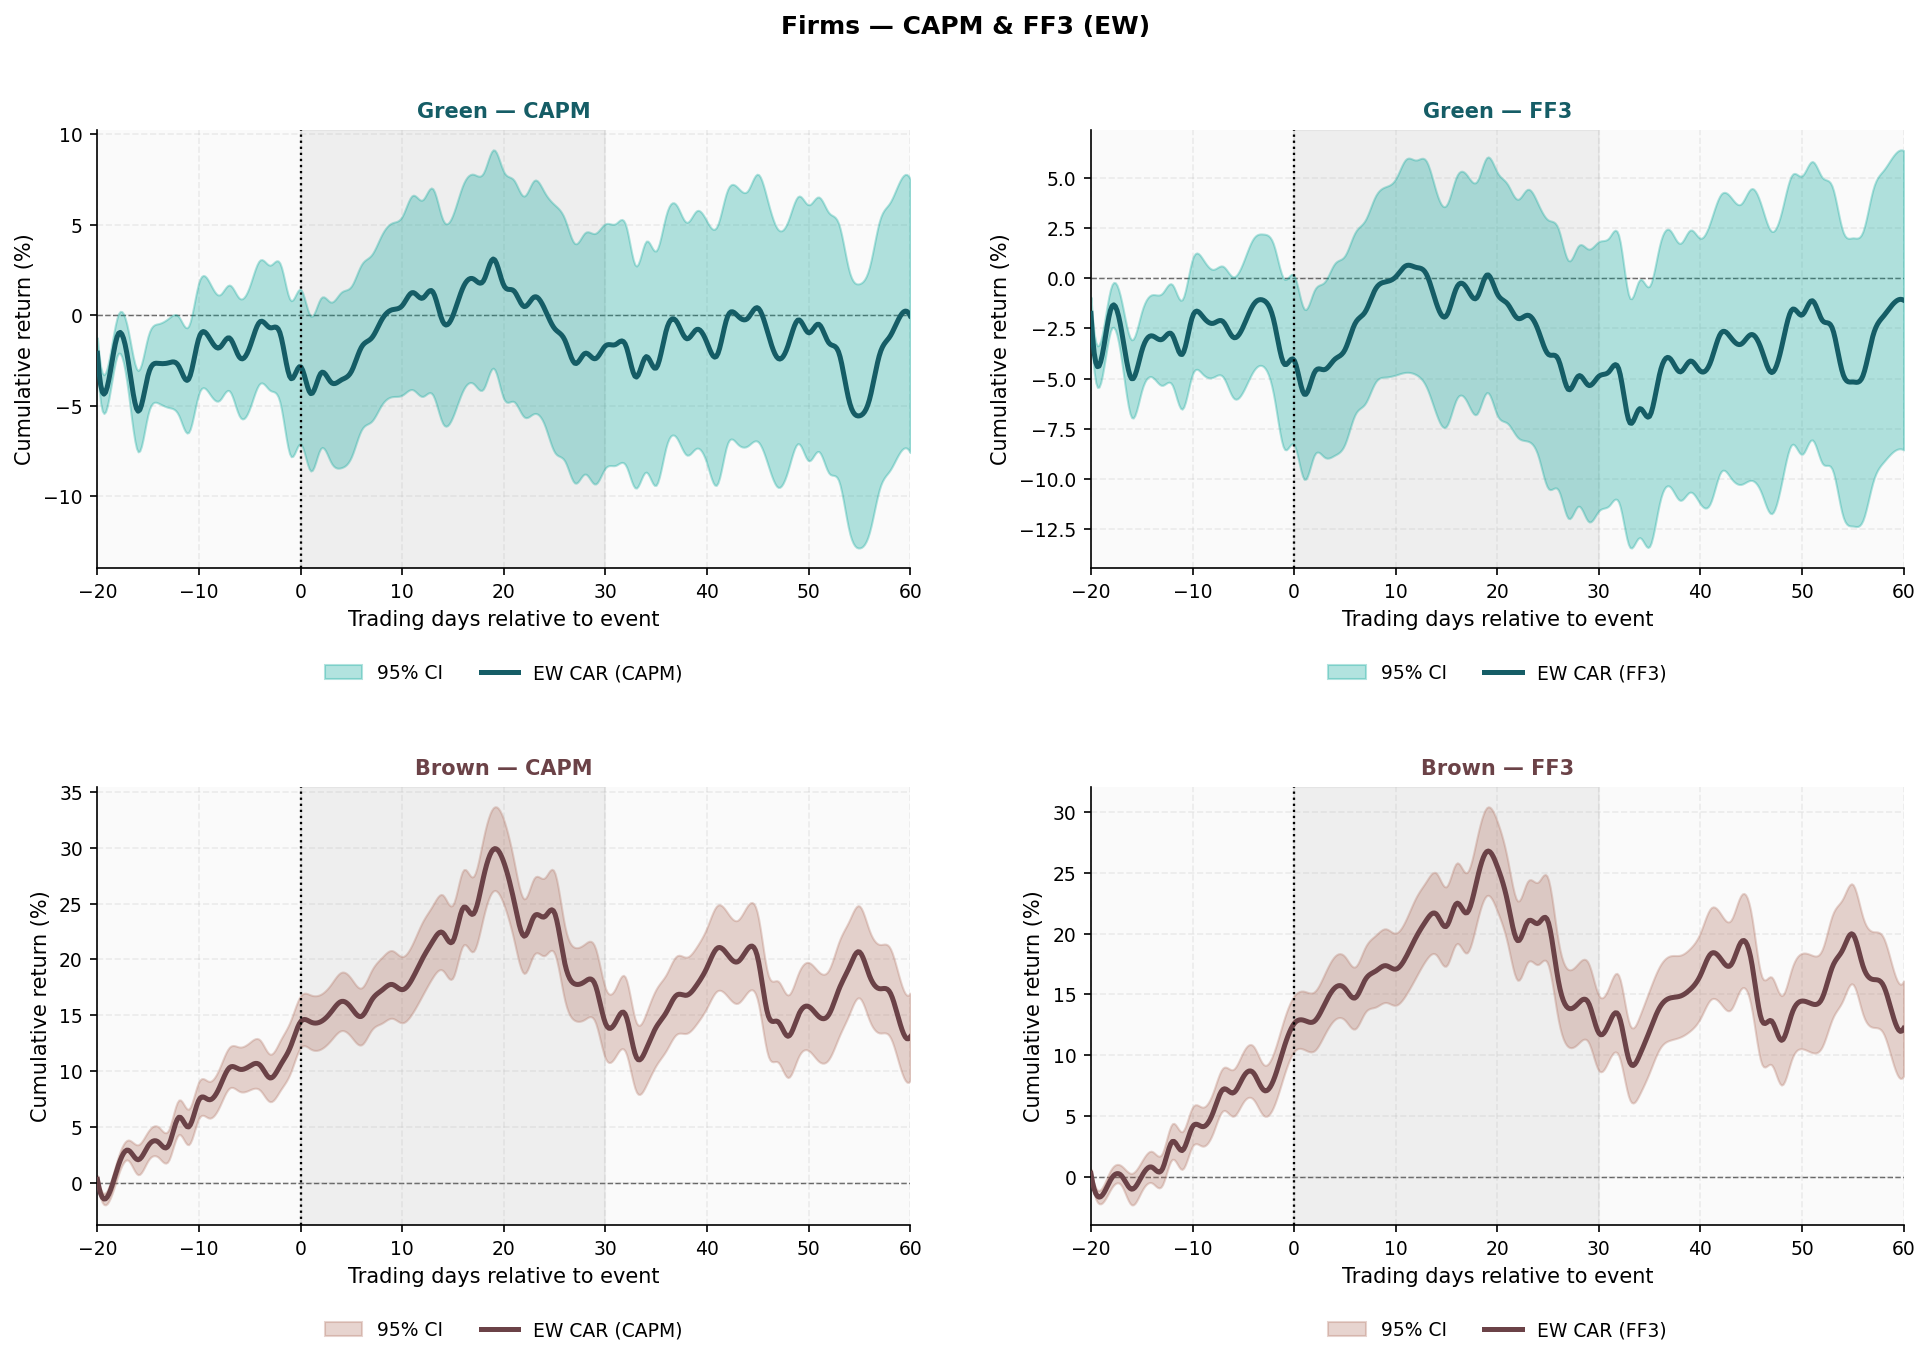

In [93]:
# ═══════════════════════════════════════════════════════════════════════════════
# CAR PATH FIGURES — EQUAL-WEIGHTED
# 4 figures: Firms base | ETFs base | Firms augmented | ETFs augmented
# Each figure: 2×2 subplots (rows = Green/Brown, cols = model pair)
# ═══════════════════════════════════════════════════════════════════════════════

def model_car_path_data_ew(ev_src, group_col, group, ar_col, t_range):
    if ev_src is None or ar_col not in ev_src.columns:
        return None

    ev_g = ev_src[
        (ev_src[group_col] == group) &
        ev_src["t"].between(*t_range)
    ].copy()

    t_vals, ar_vals, er_vals, ci_vals = [], [], [], []

    for t in range(t_range[0], t_range[1] + 1):
        day = ev_g[ev_g["t"] == t].dropna(subset=[ar_col, "excess_ret"])
        if len(day) > 0:
            ar_ew = day[ar_col].mean()
            er_ew = (day["excess_ret"] - day[ar_col]).mean()
        else:
            ar_ew = er_ew = 0.0

        t_vals.append(t)
        ar_vals.append(ar_ew)
        er_vals.append(er_ew)

        asset_cars = (
            ev_g[ev_g["t"].between(t_range[0], t) & ev_g[ar_col].notna()]
            .groupby("ric")[ar_col].sum()
        )
        if len(asset_cars) > 1:
            se = asset_cars.std(ddof=1) / np.sqrt(len(asset_cars))
            ci_vals.append(1.96 * se)
        else:
            ci_vals.append(0.0)

    cum_ar = np.cumsum(ar_vals)
    cum_er = np.cumsum(er_vals)
    ci_arr = np.array(ci_vals)

    return pd.DataFrame({
        "t":        t_vals,
        "CAR_EW":   cum_ar,
        "CI_lo":    cum_ar - ci_arr,
        "CI_hi":    cum_ar + ci_arr,
        "CumER_EW": cum_er,
    })


FIGURE_CONFIGS = [
    ("Firms — CAPM & FF3 (EW)",
     "Firms", firm_ev, "energy_type", firm_weights,
     [("CAPM", "AR_capm"), ("FF3", "AR_ff3")],
     "car_EW_Firms_base.png"),

    ("ETFs — CAPM & FF3 (EW)",
     "ETFs", etf_ev, "asset_group", etf_weights,
     [("CAPM", "AR_capm"), ("FF3", "AR_ff3")],
     "car_EW_ETFs_base.png"),

    ("Firms — CAPM+OVX & FF3+OVX (EW)",
     "Firms", firm_ev, "energy_type", firm_weights,
     [("CAPM+OVX", "AR_capm_ovx"), ("FF3+OVX", "AR_ff3_ovx")],
     "car_EW_Firms_augmented.png"),

    ("ETFs — CAPM+OVX & FF3+OVX (EW)",
     "ETFs", etf_ev, "asset_group", etf_weights,
     [("CAPM+OVX", "AR_capm_ovx"), ("FF3+OVX", "AR_ff3_ovx")],
     "car_EW_ETFs_augmented.png"),
]

for suptitle, univ_label, ev_base, group_col, weights, model_pair, fname in FIGURE_CONFIGS:

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle(suptitle, fontsize=12, fontweight="bold", y=1.01)

    for row_idx, group in enumerate(["green", "brown"]):
        color   = GREEN   if group == "green" else BROWN
        color_l = GREEN_L if group == "green" else BROWN_L
        glabel  = group.capitalize()

        for col_idx, (model_name, ar_col) in enumerate(model_pair):
            ax = axes[row_idx, col_idx]

            df = model_car_path_data_ew(
                ev_base, group_col, group, ar_col,
                (PLOT_START, PLOT_END)
            )
            if df is None:
                ax.set_visible(False)
                continue

            t        = df["t"].values
            t_smooth = np.linspace(t.min(), t.max(), 500)
            spl_car  = make_interp_spline(t, df["CAR_EW"] * 100, k=3)
            spl_lo   = make_interp_spline(t, df["CI_lo"]  * 100, k=3)
            spl_hi   = make_interp_spline(t, df["CI_hi"]  * 100, k=3)

            ax.fill_between(t_smooth, spl_lo(t_smooth), spl_hi(t_smooth),
                            color=color_l, alpha=0.30, label="95% CI", zorder=2)
            ax.plot(t_smooth, spl_car(t_smooth),
                    color=color, lw=2.4,
                    label=f"EW CAR ({model_name})", zorder=4)

            final    = spl_car(t_smooth)[-1]    

            ax.axvspan(0, 30, color="#bbbbbb", alpha=0.18, zorder=0)
            ax.axvline(0, color="black", lw=1.1, ls=":", zorder=5)
            ax.axhline(0, color=GREY,    lw=0.7, ls="--", zorder=1)
            ax.set_xlim(PLOT_START, PLOT_END)
            ax.set_xlabel("Trading days relative to event", fontsize=10)
            ax.set_ylabel("Cumulative return (%)", fontsize=10)
            ax.set_title(f"{glabel} — {model_name}",
                         color=color, fontsize=10, fontweight="semibold")
            ax.legend(frameon=False, fontsize=9,
                      loc="upper center",
                      bbox_to_anchor=(0.5, -0.18),
                      ncol=2)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    plt.tight_layout(w_pad=3.0, h_pad=4.5)
    plt.subplots_adjust(hspace=0.5)
    plt.savefig(FIG_DIR / fname, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")